# Paper 2: Mortality Prediction, Calibration, and Fairness Audit

Professor-comment response notebook prepared from `MIMIC_paper2_final_20260601_JY.docx` on 2026-06-03. This version treats 1-year mortality as the only primary modeled outcome. Cardiovascular readmission is kept only as a feasibility and temporal-drift audit because the temporal-test event count is too small for publishable prediction claims.


## 0. Running Notes

This notebook expects the frozen source analytic cohort CSV:

`analytic_dataset_paper1_primary.csv`

The manuscript should describe this as the source MIMIC-IV hypertension BPV cohort, not as a separate prior paper. The filename is preserved only because it is the existing local artifact name.

In Google Colab, run the first code cell to mount Drive. Optional packages (`shap`, `xgboost`, `lightgbm`) are installed automatically only when the notebook detects Colab.

In [1]:
# Optional Google Colab setup. This cell is safe outside Colab.
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Not running in Google Colab; using local filesystem.")

Mounted at /content/drive
Google Drive mounted.


In [2]:
# Core imports and optional package setup.
import json
import itertools
import math
import os
import re
import subprocess
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
REQUESTED_CV_FOLDS = 10
MIN_SUBGROUP_N = 100
MIN_SUBGROUP_EVENTS = 5
EXECUTION_N_JOBS = 1
RF_N_ESTIMATORS = 60
HGB_MAX_ITER = 100
MAX_PERMUTATION_ROWS = 1000
MAX_SHAP_BACKGROUND = 500
MAX_SHAP_EXPLAIN = 500

AUTO_INSTALL_OPTIONAL_IN_COLAB = True
if IN_COLAB and AUTO_INSTALL_OPTIONAL_IN_COLAB:
    for pkg in ["xgboost", "lightgbm", "shap"]:
        try:
            __import__(pkg)
        except Exception:
            print(f"Installing optional package: {pkg}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

def optional_import(module_name):
    try:
        return __import__(module_name)
    except Exception:
        return None

xgboost = optional_import("xgboost")
lightgbm = optional_import("lightgbm")
shap = optional_import("shap")

print("Optional package availability:")
print("  xgboost:", xgboost is not None)
print("  lightgbm:", lightgbm is not None)
print("  shap:", shap is not None)

Optional package availability:
  xgboost: True
  lightgbm: True
  shap: True


In [4]:
# Project paths and input discovery.
PROJECT_DIR = Path.cwd()
OUT_DIR = PROJECT_DIR / "outputs" / "paper2"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"

for p in [OUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CANDIDATE_INPUT_FILES = [
    Path("/content/drive/MyDrive/analytic_dataset_paper1_primary.csv")
]

INPUT_PATH = None
for candidate in CANDIDATE_INPUT_FILES:
    if candidate.exists():
        INPUT_PATH = candidate
        break

print("Project:", PROJECT_DIR)
print("Output directory:", OUT_DIR)
print("Searched input files:")
for candidate in CANDIDATE_INPUT_FILES:
    print(" -", candidate, "| exists:", candidate.exists())

if INPUT_PATH is None:
    raise FileNotFoundError(
        "Could not find analytic_dataset_paper1_primary.csv. "
        "Copy the frozen source cohort CSV into one of the searched paths."
    )

print("Using frozen source analytic cohort:", INPUT_PATH)

def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

def save_json(obj, name):
    path = OUT_DIR / name
    path.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    print("Saved:", path)
    return path

def display_or_print(df, n=20):
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n).to_string(index=False))

Project: /content
Output directory: /content/outputs/paper2
Searched input files:
 - /content/drive/MyDrive/analytic_dataset_paper1_primary.csv | exists: True
Using frozen source analytic cohort: /content/drive/MyDrive/analytic_dataset_paper1_primary.csv


## 1. Load Frozen Source Cohort

In [5]:
date_cols = [
    "first_htn_date", "first_bp_date", "index_date", "index_admittime",
    "index_dischtime", "index_deathtime", "dod", "censor_date_365",
    "first_readmit_time", "first_cv_readmit_time",
]

raw = pd.read_csv(INPUT_PATH, parse_dates=[c for c in date_cols if c in pd.read_csv(INPUT_PATH, nrows=0).columns])
print("Loaded cohort shape:", raw.shape)

# Normalize booleans that may arrive as strings from CSV.
bool_like = [
    "death_after_index", "death_365", "readmit_30", "readmit_365", "cv_readmit_365",
    "mace_proxy_365", "exclude_pregnancy", "exclude_esrd_dialysis",
    "exclude_no_followup", "primary_analysis_eligible",
]
for col in bool_like:
    if col in raw.columns:
        if raw[col].dtype == object:
            raw[col] = raw[col].astype(str).str.lower().map({"true": True, "false": False, "1": True, "0": False})
        raw[col] = raw[col].fillna(False).astype(bool)

cohort = raw.copy()
validation_rows = []
validation_rows.append({"step": "Loaded source cohort primary analytic cohort", "n": len(cohort), "excluded": 0})

if "primary_analysis_eligible" in cohort.columns:
    before = len(cohort)
    cohort = cohort.loc[cohort["primary_analysis_eligible"].fillna(False)].copy()
    validation_rows.append({"step": "Retain primary_analysis_eligible rows", "n": len(cohort), "excluded": before - len(cohort)})

if "age_at_index" in cohort.columns:
    before = len(cohort)
    cohort = cohort.loc[cohort["age_at_index"].isna() | (cohort["age_at_index"] >= 18)].copy()
    validation_rows.append({"step": "Explicit adult check age_at_index >=18", "n": len(cohort), "excluded": before - len(cohort)})

if {"death_365", "time_to_death_365"}.issubset(cohort.columns):
    before = len(cohort)
    bad = cohort["death_365"].fillna(False) & cohort["time_to_death_365"].notna() & (cohort["time_to_death_365"] <= 0)
    cohort = cohort.loc[~bad].copy()
    validation_rows.append({"step": "Exclude death on/before BPV index", "n": len(cohort), "excluded": before - len(cohort)})

if "days_to_cv_readmit" in cohort.columns:
    before = len(cohort)
    bad = cohort["days_to_cv_readmit"].notna() & (cohort["days_to_cv_readmit"] <= 0)
    cohort = cohort.loc[~bad].copy()
    validation_rows.append({"step": "Exclude nonpositive CV readmission time", "n": len(cohort), "excluded": before - len(cohort)})

cohort_validation = pd.DataFrame(validation_rows)
save_table(cohort_validation, "paper2_input_cohort_validation.csv")
display_or_print(cohort_validation)

target_summary = pd.DataFrame([
    {
        "target": "death_365",
        "label": "1-year all-cause mortality",
        "n": int(cohort["death_365"].notna().sum()) if "death_365" in cohort.columns else 0,
        "events": int(cohort["death_365"].fillna(False).sum()) if "death_365" in cohort.columns else np.nan,
    },
    {
        "target": "cv_readmit_365",
        "label": "1-year cardiovascular readmission",
        "n": int(cohort["cv_readmit_365"].notna().sum()) if "cv_readmit_365" in cohort.columns else 0,
        "events": int(cohort["cv_readmit_365"].fillna(False).sum()) if "cv_readmit_365" in cohort.columns else np.nan,
    },
])
target_summary["event_rate"] = target_summary["events"] / target_summary["n"]
save_table(target_summary, "paper2_target_event_summary.csv")
display_or_print(target_summary)

Loaded cohort shape: (23778, 93)
Saved: /content/outputs/paper2/tables/paper2_input_cohort_validation.csv


,step,n,excluded
0,Loaded source cohort primary analytic cohort,23778,0
1,Retain primary_analysis_eligible rows,23778,0
2,Explicit adult check age_at_index >=18,23778,0
3,Exclude death on/before BPV index,23778,0
4,Exclude nonpositive CV readmission time,23767,11


Saved: /content/outputs/paper2/tables/paper2_target_event_summary.csv


,target,label,n,events,event_rate
0,death_365,1-year all-cause mortality,23767,2067,0.086969
1,cv_readmit_365,1-year cardiovascular readmission,23767,634,0.026676


## 2. Feature Set and Leakage Audit

In [6]:
# Candidate predictors are baseline or pre-index features from the frozen source cohort.
# Outcome, follow-up, and post-outcome identifiers are excluded to avoid leakage.
numeric_candidates = [
    "age_at_index", "anchor_age", "anchor_year",
    "n_bp_dates", "bp_span_days", "mean_sbp", "mean_dbp",
    "sd_sbp", "sd_dbp", "arv_sbp", "arv_dbp", "vim_sbp", "vim_dbp",
    "cv_sbp", "cv_dbp", "bpv_z",
    "bmi", "height", "weight",
    "creatinine", "potassium", "sodium", "glucose", "hba1c",
    "hdl", "ldl", "total_cholesterol", "hemoglobin",
    "simple_comorbidity_count",
    "diabetes", "ckd", "heart_failure", "prior_mi", "stroke",
    "atrial_fibrillation", "copd",
    "acei_arb", "diuretic", "ccb", "beta_blocker", "other_antihypertensive",
    "statin", "antiplatelet_anticoagulant", "antihypertensive_class_count",
    "icu_exposure_preindex",
]

categorical_candidates = [
    "sex", "race_group", "insurance_group", "bpv_q", "anchor_year_group",
]

explicit_leakage_exclusions = [
    "death_after_index", "death_365", "time_to_death_365", "dod",
    "readmit_30", "readmit_365", "cv_readmit_365", "mace_proxy_365",
    "first_readmit_hadm_id", "first_readmit_time", "days_to_readmit",
    "first_cv_readmit_hadm_id", "first_cv_readmit_time", "days_to_cv_readmit",
    "in_hospital_mortality_index", "index_hospital_expire_flag", "index_deathtime",
    "censor_date_365", "exclude_pregnancy", "exclude_esrd_dialysis",
    "exclude_no_followup", "primary_analysis_eligible",
    "index_hadm_id", "subject_id",
]

# High-missingness biomarkers are excluded from the default predictive feature set.
missing_fraction = cohort.isna().mean()
high_missing_exclusions = [
    c for c in ["egfr_omr", "troponin", "bnp_ntprobnp"] if c in cohort.columns and missing_fraction[c] > 0.80
]

numeric_features = [c for c in numeric_candidates if c in cohort.columns and c not in high_missing_exclusions]
categorical_features = [c for c in categorical_candidates if c in cohort.columns and c not in high_missing_exclusions]
feature_cols = numeric_features + categorical_features

# Remove accidental leakage if a future edit adds a forbidden column to candidate lists.
feature_cols = [c for c in feature_cols if c not in explicit_leakage_exclusions]
numeric_features = [c for c in numeric_features if c in feature_cols]
categorical_features = [c for c in categorical_features if c in feature_cols]

feature_dictionary = pd.DataFrame(
    [{"variable": c, "role": "numeric_predictor", "missing_fraction": missing_fraction.get(c, np.nan)} for c in numeric_features]
    + [{"variable": c, "role": "categorical_predictor", "missing_fraction": missing_fraction.get(c, np.nan)} for c in categorical_features]
    + [{"variable": c, "role": "excluded_leakage_or_outcome", "missing_fraction": missing_fraction.get(c, np.nan)} for c in explicit_leakage_exclusions if c in cohort.columns]
    + [{"variable": c, "role": "excluded_high_missingness", "missing_fraction": missing_fraction.get(c, np.nan)} for c in high_missing_exclusions]
)

save_table(feature_dictionary, "paper2_feature_dictionary_and_leakage_audit.csv")
display_or_print(feature_dictionary.sort_values(["role", "variable"]), n=80)

missingness = (
    cohort[feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "variable"})
)
save_table(missingness, "paper2_predictor_missingness_summary.csv")
display_or_print(missingness, n=80)

if not feature_cols:
    raise ValueError("No prediction features are available after leakage filtering.")

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total model features:", len(feature_cols))

Saved: /content/outputs/paper2/tables/paper2_feature_dictionary_and_leakage_audit.csv


,variable,role,missing_fraction
49,anchor_year_group,categorical_predictor,0.000000
48,bpv_q,categorical_predictor,0.000000
47,insurance_group,categorical_predictor,0.000000
46,race_group,categorical_predictor,0.000000
45,sex,categorical_predictor,0.000000
...,...,...,...
33,stroke,numeric_predictor,0.000000
26,total_cholesterol,numeric_predictor,0.347835
12,vim_dbp,numeric_predictor,0.000000
11,vim_sbp,numeric_predictor,0.000000


Saved: /content/outputs/paper2/tables/paper2_predictor_missingness_summary.csv


,variable,missing_fraction
0,hba1c,0.417133
1,ldl,0.355240
2,hdl,0.355198
3,total_cholesterol,0.347835
4,height,0.125384
5,bmi,0.079522
6,weight,0.016830
7,glucose,0.007111
8,sodium,0.003745
9,potassium,0.003450


Numeric features: 45
Categorical features: 5
Total model features: 50


## 3. Temporal Train/Test Split

In [7]:
def anchor_group_start_year(value):
    match = re.search(r"\d{4}", str(value))
    if match:
        return int(match.group(0))
    return -1

if "anchor_year_group" not in cohort.columns:
    raise ValueError("anchor_year_group is required for the pre-specified temporal validation split.")

groups_sorted = sorted(cohort["anchor_year_group"].dropna().astype(str).unique(), key=anchor_group_start_year)
if len(groups_sorted) < 2:
    raise ValueError("At least two anchor_year_group values are needed for temporal validation.")

TEST_ANCHOR_YEAR_GROUP = groups_sorted[-1]
TRAIN_ANCHOR_YEAR_GROUPS = groups_sorted[:-1]

cohort["paper2_split"] = np.where(
    cohort["anchor_year_group"].astype(str).eq(TEST_ANCHOR_YEAR_GROUP),
    "temporal_test",
    "train_cv",
)

split_summary = (
    cohort.groupby(["paper2_split", "anchor_year_group"], dropna=False)
    .agg(
        n=("subject_id", "size") if "subject_id" in cohort.columns else ("paper2_split", "size"),
        death_events=("death_365", "sum"),
        cv_readmit_events=("cv_readmit_365", "sum"),
    )
    .reset_index()
    .sort_values(["paper2_split", "anchor_year_group"])
)

save_table(split_summary, "paper2_temporal_split_summary.csv")
display_or_print(split_summary, n=20)

print("Training groups:", TRAIN_ANCHOR_YEAR_GROUPS)
print("Held-out temporal test group:", TEST_ANCHOR_YEAR_GROUP)

Saved: /content/outputs/paper2/tables/paper2_temporal_split_summary.csv


,paper2_split,anchor_year_group,n,death_events,cv_readmit_events
0,temporal_test,2017 - 2019,4312,383,13
1,train_cv,2008 - 2010,8387,701,372
2,train_cv,2011 - 2013,5771,485,159
3,train_cv,2014 - 2016,5297,498,90


Training groups: ['2008 - 2010', '2011 - 2013', '2014 - 2016']
Held-out temporal test group: 2017 - 2019


## 4. Modeling Helpers

In [8]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor():
    transformers = []
    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline(
                    steps=[
                        ("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                numeric_features,
            )
        )
    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("impute", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_onehot_encoder()),
                    ]
                ),
                categorical_features,
            )
        )
    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.0)

def make_gradient_boosting_model(y_train=None):
    # Prefer XGBoost/LightGBM when available; otherwise use sklearn HistGradientBoosting.
    if xgboost is not None:
        pos = float(np.sum(y_train == 1)) if y_train is not None else 1.0
        neg = float(np.sum(y_train == 0)) if y_train is not None else 1.0
        scale_pos_weight = neg / max(pos, 1.0)
        return xgboost.XGBClassifier(
            n_estimators=180,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=EXECUTION_N_JOBS,
            scale_pos_weight=scale_pos_weight,
        ), "XGBoost"
    if lightgbm is not None:
        return lightgbm.LGBMClassifier(
            n_estimators=220,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=EXECUTION_N_JOBS,
            verbose=-1,
        ), "LightGBM"
    return HistGradientBoostingClassifier(
        max_iter=HGB_MAX_ITER,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ), "HistGradientBoosting"

def make_model_specs(y_train):
    gb_model, gb_name = make_gradient_boosting_model(y_train)
    return {
        "ElasticNetLogistic": SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            alpha=0.0005,
            l1_ratio=0.5,
            max_iter=1000,
            tol=1e-3,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            max_depth=None,
            min_samples_leaf=20,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=EXECUTION_N_JOBS,
        ),
        gb_name: gb_model,
    }

def make_pipeline(estimator):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", estimator),
        ]
    )

def predict_proba_positive(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2:
        return proba[:, 1]
    return proba

def safe_auc(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan

def safe_auprc(y, p):
    return average_precision_score(y, p) if len(np.unique(y)) == 2 else np.nan

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int)
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    if len(np.unique(y)) < 2:
        return np.nan, np.nan
    logit_p = np.log(p / (1 - p)).reshape(-1, 1)
    try:
        cal = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
    except TypeError:
        cal = LogisticRegression(penalty="none", solver="lbfgs", max_iter=1000)
    cal.fit(logit_p, y)
    return float(cal.intercept_[0]), float(cal.coef_[0][0])

def metric_row(y, p, label, target_key, model_name, split_name):
    y = pd.Series(y).astype(int).values
    p = np.asarray(p, dtype=float)
    intercept, slope = calibration_intercept_slope(y, p)
    return {
        "target": target_key,
        "target_label": label,
        "model": model_name,
        "split": split_name,
        "n": int(len(y)),
        "events": int(y.sum()),
        "event_rate": float(y.mean()),
        "auroc": safe_auc(y, p),
        "auprc": safe_auprc(y, p),
        "brier": brier_score_loss(y, p),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
    }

def choose_threshold_youden(y, p):
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    if len(np.unique(y)) < 2:
        return float(np.nanmedian(p))
    fpr, tpr, thresholds = roc_curve(y, p)
    idx = int(np.nanargmax(tpr - fpr))
    threshold = thresholds[idx]
    if not np.isfinite(threshold):
        threshold = np.quantile(p, 0.90)
    return float(np.clip(threshold, 0.001, 0.999))

def threshold_metrics(y, p, threshold):
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    return {
        "threshold": threshold,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "sensitivity_tpr": sensitivity,
        "specificity_tnr": specificity,
        "fpr": fpr,
        "fnr": fnr,
        "ppv": ppv,
        "npv": npv,
    }

def decision_curve_rows(y, p, thresholds, target_key, model_name):
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    n = len(y)
    rows = []
    for threshold in thresholds:
        pred = p >= threshold
        tp = np.sum(pred & (y == 1))
        fp = np.sum(pred & (y == 0))
        nb = (tp / n) - (fp / n) * (threshold / (1 - threshold))
        rows.append(
            {
                "target": target_key,
                "model": model_name,
                "threshold": threshold,
                "net_benefit": nb,
            }
        )
    return rows

## 5. Fit Models, Cross-Validate, and Evaluate Temporal Test Performance

In [9]:
TARGETS = {
    "mortality_365": {"column": "death_365", "label": "1-year all-cause mortality"},
}

REMOVED_OUTCOMES = {
    "cv_readmission_365": {
        "column": "cv_readmit_365",
        "label": "1-year cardiovascular readmission",
        "reason": (
            "Removed from primary prediction modeling because the temporal-test set has only "
            "13 events (~0.30%), making discrimination, calibration, and fairness estimates unstable."
        ),
    }
}

fitted_models = {}
prediction_frames = []
performance_rows = []
cv_rows = []
threshold_rows = []
dca_rows = []

thresholds_for_dca = np.round(np.linspace(0.01, 0.50, 50), 3)

for target_key, target_info in TARGETS.items():
    target_col = target_info["column"]
    target_label = target_info["label"]
    if target_col not in cohort.columns:
        raise ValueError(f"Target column missing: {target_col}")

    model_data = cohort.dropna(subset=[target_col, "paper2_split"]).copy()
    model_data[target_col] = model_data[target_col].astype(int)

    train_mask = model_data["paper2_split"].eq("train_cv")
    test_mask = model_data["paper2_split"].eq("temporal_test")

    X_train = model_data.loc[train_mask, feature_cols].copy()
    y_train = model_data.loc[train_mask, target_col].astype(int).copy()
    X_test = model_data.loc[test_mask, feature_cols].copy()
    y_test = model_data.loc[test_mask, target_col].astype(int).copy()

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        raise ValueError(f"Target {target_key} lacks both classes in train or test.")

    event_count = int(y_train.sum())
    non_event_count = int((1 - y_train).sum())
    actual_cv_folds = min(REQUESTED_CV_FOLDS, event_count, non_event_count)
    if actual_cv_folds < 2:
        raise ValueError(f"Insufficient events for CV for target {target_key}.")

    cv = StratifiedKFold(n_splits=actual_cv_folds, shuffle=True, random_state=RANDOM_STATE)
    model_specs = make_model_specs(y_train.values)
    fitted_models[target_key] = {}

    for model_name, estimator in model_specs.items():
        print(f"\nTarget: {target_label} | Model: {model_name}")
        pipe = make_pipeline(estimator)

        cv_result = cross_validate(
            clone(pipe),
            X_train,
            y_train,
            cv=cv,
            scoring={
                "auroc": "roc_auc",
                "auprc": "average_precision",
                "brier": "neg_brier_score",
            },
            n_jobs=EXECUTION_N_JOBS,
            return_train_score=False,
            error_score=np.nan,
        )
        cv_rows.append(
            {
                "target": target_key,
                "target_label": target_label,
                "model": model_name,
                "requested_folds": REQUESTED_CV_FOLDS,
                "actual_folds": actual_cv_folds,
                "cv_auroc_mean": np.nanmean(cv_result["test_auroc"]),
                "cv_auroc_sd": np.nanstd(cv_result["test_auroc"]),
                "cv_auprc_mean": np.nanmean(cv_result["test_auprc"]),
                "cv_auprc_sd": np.nanstd(cv_result["test_auprc"]),
                "cv_brier_mean": -np.nanmean(cv_result["test_brier"]),
                "cv_brier_sd": np.nanstd(-cv_result["test_brier"]),
            }
        )

        pipe.fit(X_train, y_train)
        fitted_models[target_key][model_name] = pipe

        p_train = predict_proba_positive(pipe, X_train)
        p_test = predict_proba_positive(pipe, X_test)
        threshold = choose_threshold_youden(y_train, p_train)

        performance_rows.append(metric_row(y_train, p_train, target_label, target_key, model_name, "train_cv_refit"))
        performance_rows.append(metric_row(y_test, p_test, target_label, target_key, model_name, "temporal_test"))

        tm = threshold_metrics(y_test, p_test, threshold)
        tm.update({"target": target_key, "target_label": target_label, "model": model_name, "threshold_source": "train_cv_youden"})
        threshold_rows.append(tm)

        for row in decision_curve_rows(y_test, p_test, thresholds_for_dca, target_key, model_name):
            dca_rows.append(row)

        pred = model_data.loc[test_mask, ["paper2_split", "anchor_year_group", "sex", "race_group", "insurance_group"]].copy()
        if "subject_id" in model_data.columns:
            pred.insert(0, "subject_id", model_data.loc[test_mask, "subject_id"].values)
        pred["target"] = target_key
        pred["target_label"] = target_label
        pred["model"] = model_name
        pred["y_true"] = y_test.values
        pred["predicted_risk"] = p_test
        pred["threshold"] = threshold
        pred["predicted_positive"] = (p_test >= threshold).astype(int)
        prediction_frames.append(pred)

model_performance = pd.DataFrame(performance_rows)
cv_performance = pd.DataFrame(cv_rows)
thresholds_table = pd.DataFrame(threshold_rows)
prediction_test = pd.concat(prediction_frames, ignore_index=True)
dca = pd.DataFrame(dca_rows)

save_table(model_performance, "table7_model_performance_temporal_and_train.csv")
save_table(cv_performance, "table7_model_performance_10fold_cv_train.csv")
save_table(thresholds_table, "table7d_model_threshold_metrics_temporal_test.csv")
save_table(prediction_test, "paper2_temporal_test_predictions_all_models.csv")
save_table(dca, "paper2_decision_curve_net_benefit.csv")

display_or_print(model_performance.sort_values(["target", "split", "model"]), n=50)
display_or_print(cv_performance.sort_values(["target", "model"]), n=50)


Target: 1-year all-cause mortality | Model: ElasticNetLogistic

Target: 1-year all-cause mortality | Model: RandomForest

Target: 1-year all-cause mortality | Model: XGBoost
Saved: /content/outputs/paper2/tables/table7_model_performance_temporal_and_train.csv
Saved: /content/outputs/paper2/tables/table7_model_performance_10fold_cv_train.csv
Saved: /content/outputs/paper2/tables/table7d_model_threshold_metrics_temporal_test.csv
Saved: /content/outputs/paper2/tables/paper2_temporal_test_predictions_all_models.csv
Saved: /content/outputs/paper2/tables/paper2_decision_curve_net_benefit.csv


,target,target_label,model,split,n,events,event_rate,auroc,auprc,brier,calibration_intercept,calibration_slope
1,mortality_365,1-year all-cause mortality,ElasticNetLogistic,temporal_test,4312,383,0.088822,0.822156,0.340263,0.110237,-1.771953,0.485019
3,mortality_365,1-year all-cause mortality,RandomForest,temporal_test,4312,383,0.088822,0.859937,0.467933,0.116880,-1.651231,1.709752
5,mortality_365,1-year all-cause mortality,XGBoost,temporal_test,4312,383,0.088822,0.875706,0.512767,0.163332,-2.570688,1.218860
0,mortality_365,1-year all-cause mortality,ElasticNetLogistic,train_cv_refit,19455,1684,0.086559,0.818415,0.290035,0.179053,-2.291866,0.399377
2,mortality_365,1-year all-cause mortality,RandomForest,train_cv_refit,19455,1684,0.086559,0.973212,0.775371,0.082686,-1.844006,3.200881
4,mortality_365,1-year all-cause mortality,XGBoost,train_cv_refit,19455,1684,0.086559,0.918072,0.586532,0.120875,-2.347820,1.403996


,target,target_label,model,requested_folds,actual_folds,cv_auroc_mean,cv_auroc_sd,cv_auprc_mean,cv_auprc_sd,cv_brier_mean,cv_brier_sd
0,mortality_365,1-year all-cause mortality,ElasticNetLogistic,10,10,0.813642,0.032745,0.312305,0.061103,0.173472,0.038930
1,mortality_365,1-year all-cause mortality,RandomForest,10,10,0.868470,0.012793,0.452509,0.042713,0.101543,0.002243
2,mortality_365,1-year all-cause mortality,XGBoost,10,10,0.882699,0.010497,0.514718,0.041179,0.126830,0.001866


## 6. Select Primary Model Per Target

In [10]:
test_perf = model_performance[model_performance["split"].eq("temporal_test")].copy()
test_perf = test_perf.sort_values(["target", "auroc", "auprc"], ascending=[True, False, False])
primary_model_selection = test_perf.groupby("target", as_index=False).head(1).copy()
primary_model_selection["selection_rule"] = "Highest temporal-test AUROC; AUPRC as tie-breaker"

save_table(primary_model_selection, "paper2_primary_model_selection.csv")
display_or_print(primary_model_selection, n=10)

primary_models = dict(zip(primary_model_selection["target"], primary_model_selection["model"]))
print("Primary models:", primary_models)

Saved: /content/outputs/paper2/tables/paper2_primary_model_selection.csv


,target,target_label,model,split,n,events,event_rate,auroc,auprc,brier,calibration_intercept,calibration_slope,selection_rule
5,mortality_365,1-year all-cause mortality,XGBoost,temporal_test,4312,383,0.088822,0.875706,0.512767,0.163332,-2.570688,1.21886,Highest temporal-test AUROC; AUPRC as tie-breaker


Primary models: {'mortality_365': 'XGBoost'}


## 7. Figure 8: ROC, Precision-Recall, Calibration, and Decision Curves

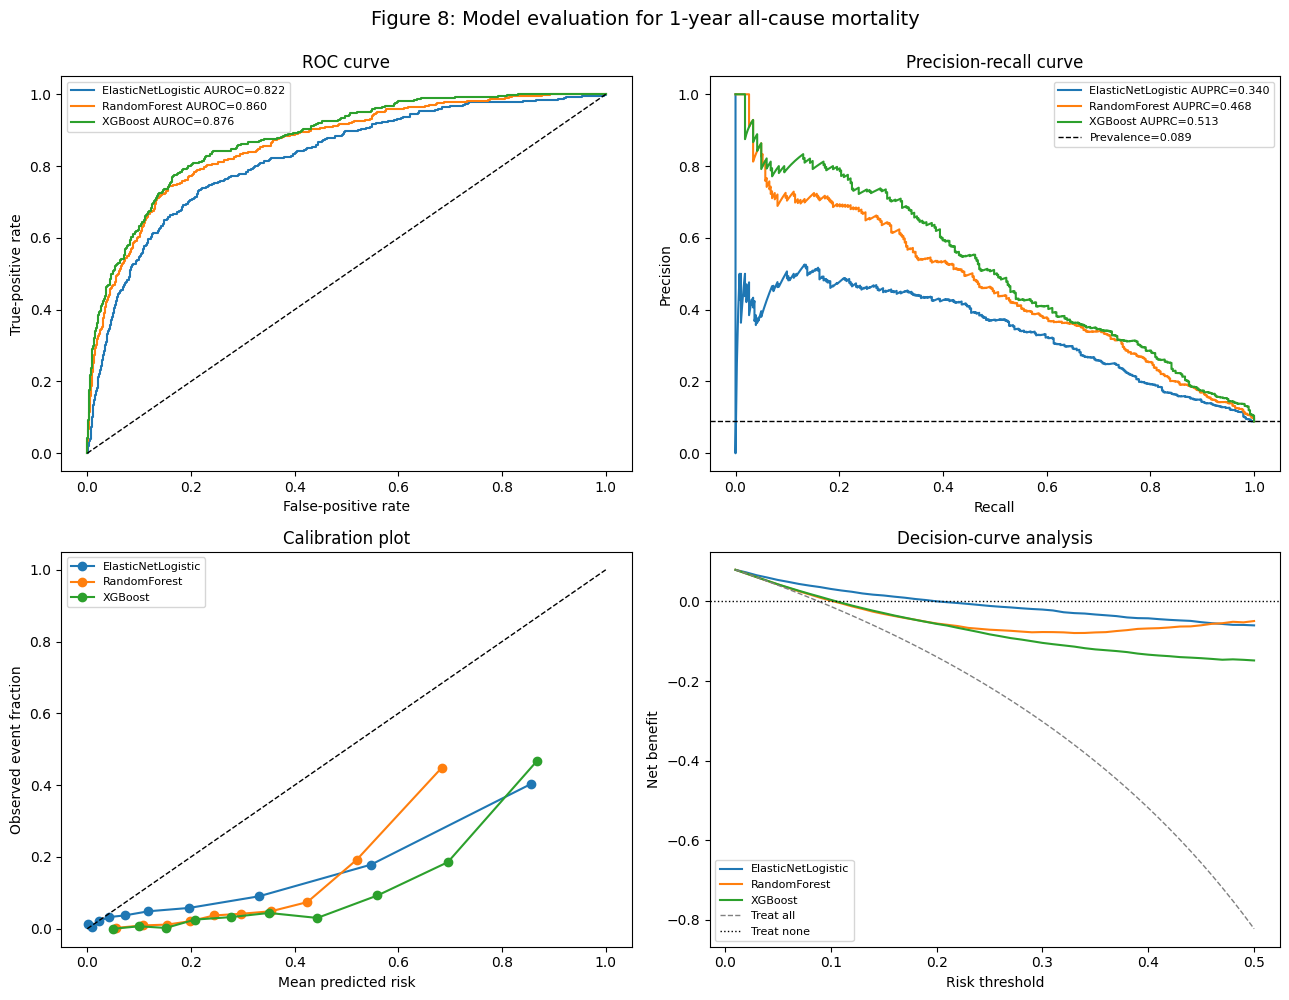

Saved: /content/outputs/paper2/figures/figure8_mortality_365_model_evaluation.png


In [11]:
def plot_evaluation_panel(target_key):
    target_label = TARGETS[target_key]["label"]
    pred = prediction_test[prediction_test["target"].eq(target_key)].copy()
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # ROC
    for model_name, sub in pred.groupby("model"):
        if sub["y_true"].nunique() == 2:
            fpr, tpr, _ = roc_curve(sub["y_true"], sub["predicted_risk"])
            auc = roc_auc_score(sub["y_true"], sub["predicted_risk"])
            axes[0, 0].plot(fpr, tpr, label=f"{model_name} AUROC={auc:.3f}")
    axes[0, 0].plot([0, 1], [0, 1], color="black", lw=1, ls="--")
    axes[0, 0].set_title("ROC curve")
    axes[0, 0].set_xlabel("False-positive rate")
    axes[0, 0].set_ylabel("True-positive rate")
    axes[0, 0].legend(fontsize=8)

    # Precision-recall
    prevalence = pred["y_true"].mean()
    for model_name, sub in pred.groupby("model"):
        precision, recall, _ = precision_recall_curve(sub["y_true"], sub["predicted_risk"])
        ap = average_precision_score(sub["y_true"], sub["predicted_risk"])
        axes[0, 1].plot(recall, precision, label=f"{model_name} AUPRC={ap:.3f}")
    axes[0, 1].axhline(prevalence, color="black", lw=1, ls="--", label=f"Prevalence={prevalence:.3f}")
    axes[0, 1].set_title("Precision-recall curve")
    axes[0, 1].set_xlabel("Recall")
    axes[0, 1].set_ylabel("Precision")
    axes[0, 1].legend(fontsize=8)

    # Calibration
    for model_name, sub in pred.groupby("model"):
        frac_pos, mean_pred = calibration_curve(sub["y_true"], sub["predicted_risk"], n_bins=10, strategy="quantile")
        axes[1, 0].plot(mean_pred, frac_pos, marker="o", label=model_name)
    axes[1, 0].plot([0, 1], [0, 1], color="black", lw=1, ls="--")
    axes[1, 0].set_title("Calibration plot")
    axes[1, 0].set_xlabel("Mean predicted risk")
    axes[1, 0].set_ylabel("Observed event fraction")
    axes[1, 0].legend(fontsize=8)

    # Decision curve
    dca_sub = dca[dca["target"].eq(target_key)].copy()
    for model_name, sub in dca_sub.groupby("model"):
        axes[1, 1].plot(sub["threshold"], sub["net_benefit"], label=model_name)
    thresholds = thresholds_for_dca
    treat_all = prevalence - (1 - prevalence) * thresholds / (1 - thresholds)
    axes[1, 1].plot(thresholds, treat_all, color="gray", lw=1, ls="--", label="Treat all")
    axes[1, 1].axhline(0, color="black", lw=1, ls=":", label="Treat none")
    axes[1, 1].set_title("Decision-curve analysis")
    axes[1, 1].set_xlabel("Risk threshold")
    axes[1, 1].set_ylabel("Net benefit")
    axes[1, 1].legend(fontsize=8)

    fig.suptitle(f"Figure 8: Model evaluation for {target_label}", y=0.995, fontsize=14)
    plt.tight_layout()
    path = FIG_DIR / f"figure8_{target_key}_model_evaluation.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

for target_key in TARGETS:
    plot_evaluation_panel(target_key)

## 8. Interpretability: SHAP When Available, Otherwise Permutation Importance

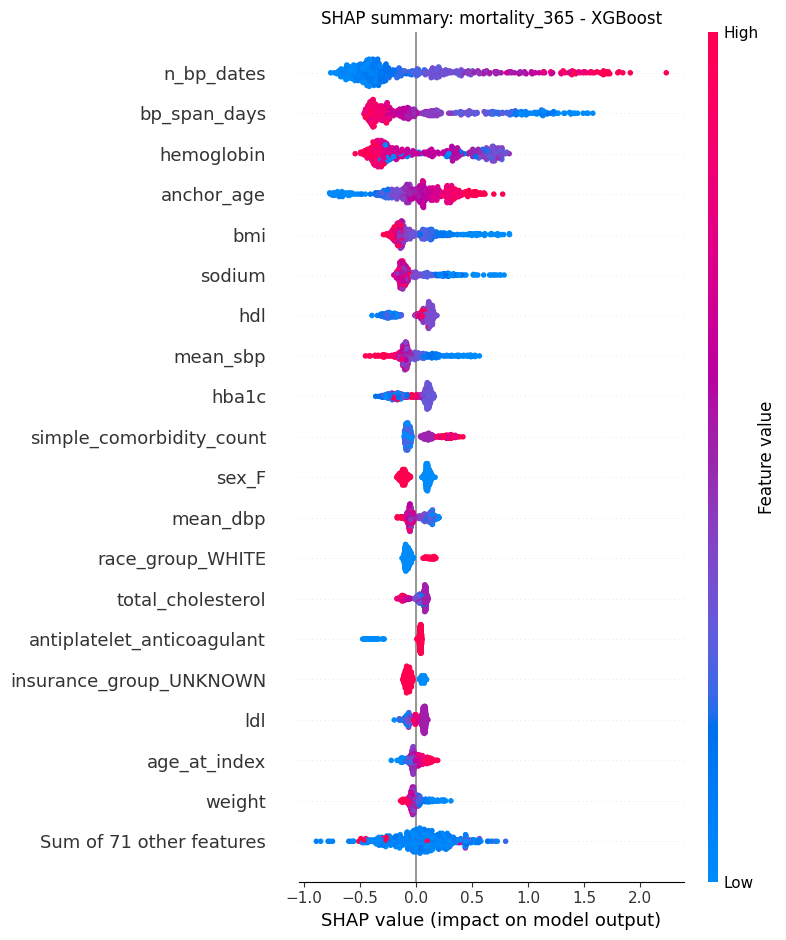

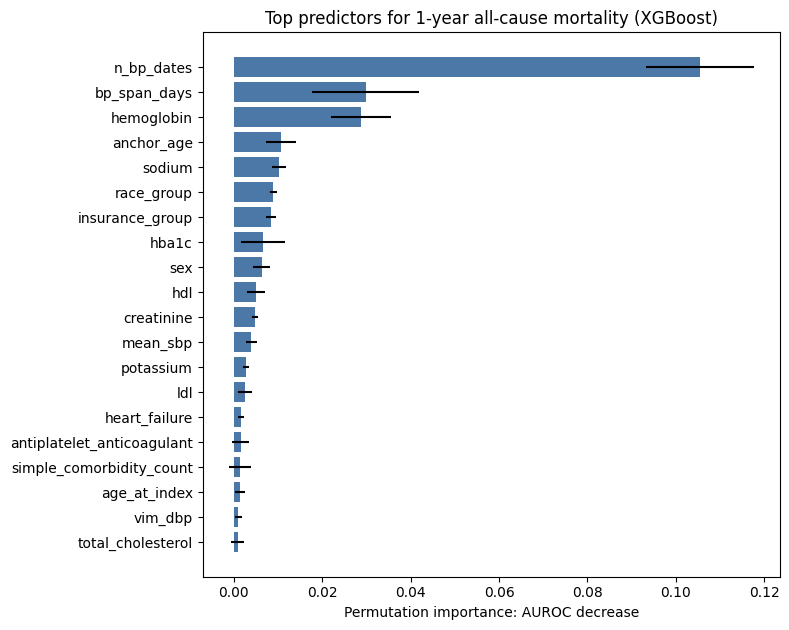

Saved: /content/outputs/paper2/figures/figure8_mortality_365_permutation_importance_XGBoost.png
Saved: /content/outputs/paper2/tables/paper2_primary_model_permutation_importance.csv
Saved: /content/outputs/paper2/tables/paper2_interpretability_status.csv


,target,model,shap_figure,status
0,mortality_365,XGBoost,/content/outputs/paper2/figures/figure8_mortal...,SHAP summary generated.


In [12]:
importance_rows = []

def get_feature_names_from_pipeline(pipe):
    pre = pipe.named_steps["preprocess"]
    names = []
    if "num" in pre.named_transformers_:
        names.extend(numeric_features)
    if "cat" in pre.named_transformers_:
        cat_pipe = pre.named_transformers_["cat"]
        encoder = cat_pipe.named_steps["onehot"]
        try:
            names.extend(encoder.get_feature_names_out(categorical_features).tolist())
        except Exception:
            names.extend(categorical_features)
    return names

def save_permutation_importance(target_key, model_name, pipe, X_test, y_test):
    if len(X_test) > MAX_PERMUTATION_ROWS:
        sample_idx = X_test.sample(MAX_PERMUTATION_ROWS, random_state=RANDOM_STATE).index
        X_imp = X_test.loc[sample_idx]
        y_imp = y_test.loc[sample_idx]
    else:
        X_imp = X_test
        y_imp = y_test
    result = permutation_importance(
        pipe,
        X_imp,
        y_imp,
        scoring="roc_auc",
        n_repeats=4,
        random_state=RANDOM_STATE,
        n_jobs=EXECUTION_N_JOBS,
    )
    imp = pd.DataFrame(
        {
            "target": target_key,
            "model": model_name,
            "variable": feature_cols,
            "importance_mean": result.importances_mean,
            "importance_sd": result.importances_std,
            "importance_type": "permutation_auc_drop",
        }
    ).sort_values("importance_mean", ascending=False)
    return imp

def try_save_shap_summary(target_key, model_name, pipe, X_train, X_test):
    if shap is None:
        return None, "SHAP package not available; used permutation importance."
    try:
        X_background = X_train.sample(min(MAX_SHAP_BACKGROUND, len(X_train)), random_state=RANDOM_STATE)
        X_explain = X_test.sample(min(MAX_SHAP_EXPLAIN, len(X_test)), random_state=RANDOM_STATE)
        pre = pipe.named_steps["preprocess"]
        model = pipe.named_steps["model"]
        background_t = pre.transform(X_background)
        explain_t = pre.transform(X_explain)
        feature_names = get_feature_names_from_pipeline(pipe)
        explainer = shap.Explainer(model, background_t, feature_names=feature_names)
        shap_values = explainer(explain_t)
        plt.figure(figsize=(9, 7))
        shap.plots.beeswarm(shap_values, max_display=20, show=False)
        plt.title(f"SHAP summary: {target_key} - {model_name}")
        path = FIG_DIR / f"figure8_{target_key}_shap_summary_{model_name}.png"
        plt.tight_layout()
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        return path, "SHAP summary generated."
    except Exception as exc:
        return None, f"SHAP failed ({exc}); used permutation importance."

interpretability_status = []

for target_key, model_name in primary_models.items():
    target_col = TARGETS[target_key]["column"]
    model_data = cohort.dropna(subset=[target_col, "paper2_split"]).copy()
    model_data[target_col] = model_data[target_col].astype(int)
    train_mask = model_data["paper2_split"].eq("train_cv")
    test_mask = model_data["paper2_split"].eq("temporal_test")
    X_train = model_data.loc[train_mask, feature_cols].copy()
    X_test = model_data.loc[test_mask, feature_cols].copy()
    y_test = model_data.loc[test_mask, target_col].astype(int).copy()
    pipe = fitted_models[target_key][model_name]

    shap_path, status = try_save_shap_summary(target_key, model_name, pipe, X_train, X_test)
    interpretability_status.append(
        {
            "target": target_key,
            "model": model_name,
            "shap_figure": str(shap_path) if shap_path else "",
            "status": status,
        }
    )

    imp = save_permutation_importance(target_key, model_name, pipe, X_test, y_test)
    importance_rows.append(imp)

    top = imp.head(20).sort_values("importance_mean", ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(top))))
    ax.barh(top["variable"], top["importance_mean"], xerr=top["importance_sd"], color="#4C78A8")
    ax.set_xlabel("Permutation importance: AUROC decrease")
    ax.set_title(f"Top predictors for {TARGETS[target_key]['label']} ({model_name})")
    plt.tight_layout()
    path = FIG_DIR / f"figure8_{target_key}_permutation_importance_{model_name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

importance_table = pd.concat(importance_rows, ignore_index=True)
interpretability_status = pd.DataFrame(interpretability_status)
save_table(importance_table, "paper2_primary_model_permutation_importance.csv")
save_table(interpretability_status, "paper2_interpretability_status.csv")
display_or_print(interpretability_status, n=20)

## 9. Fairness Audit by Race, Sex, and Insurance

In [13]:
FAIRNESS_ATTRIBUTES = [c for c in ["race_group", "sex", "insurance_group"] if c in cohort.columns]

def subgroup_metric_rows(pred_df, target_key, model_name, attribute):
    rows = []
    threshold = float(pred_df["threshold"].iloc[0])
    for level, sub in pred_df.groupby(attribute, dropna=False):
        y = sub["y_true"].astype(int).values
        p = sub["predicted_risk"].astype(float).values
        n = len(sub)
        events = int(y.sum())
        nonevents = int(n - events)
        if n < MIN_SUBGROUP_N or events < MIN_SUBGROUP_EVENTS or nonevents < MIN_SUBGROUP_EVENTS:
            rows.append(
                {
                    "target": target_key,
                    "model": model_name,
                    "attribute": attribute,
                    "level": str(level),
                    "n": n,
                    "events": events,
                    "status": "skipped_small_or_single_class",
                }
            )
            continue
        intercept, slope = calibration_intercept_slope(y, p)
        tm = threshold_metrics(y, p, threshold)
        row = {
            "target": target_key,
            "model": model_name,
            "attribute": attribute,
            "level": str(level),
            "n": n,
            "events": events,
            "event_rate": float(np.mean(y)),
            "auroc": safe_auc(y, p),
            "auprc": safe_auprc(y, p),
            "brier": brier_score_loss(y, p),
            "calibration_intercept": intercept,
            "calibration_slope": slope,
            "status": "estimated",
        }
        row.update(tm)
        rows.append(row)
    return rows

subgroup_rows = []
disparity_rows = []

for target_key, model_name in primary_models.items():
    pred = prediction_test[
        prediction_test["target"].eq(target_key) & prediction_test["model"].eq(model_name)
    ].copy()
    for attr in FAIRNESS_ATTRIBUTES:
        subgroup_rows.extend(subgroup_metric_rows(pred, target_key, model_name, attr))

subgroup_fairness = pd.DataFrame(subgroup_rows)
save_table(subgroup_fairness, "table7b_primary_model_subgroup_performance_fairness.csv")

for (target_key, model_name, attr), sub in subgroup_fairness[subgroup_fairness["status"].eq("estimated")].groupby(["target", "model", "attribute"]):
    row = {
        "target": target_key,
        "model": model_name,
        "attribute": attr,
        "n_groups_estimated": int(sub["level"].nunique()),
        "auroc_range": float(sub["auroc"].max() - sub["auroc"].min()) if sub["auroc"].notna().sum() else np.nan,
        "calibration_intercept_range": float(sub["calibration_intercept"].max() - sub["calibration_intercept"].min()) if sub["calibration_intercept"].notna().sum() else np.nan,
        "fnr_range": float(sub["fnr"].max() - sub["fnr"].min()) if sub["fnr"].notna().sum() else np.nan,
        "fpr_range": float(sub["fpr"].max() - sub["fpr"].min()) if sub["fpr"].notna().sum() else np.nan,
        "tpr_range": float(sub["sensitivity_tpr"].max() - sub["sensitivity_tpr"].min()) if sub["sensitivity_tpr"].notna().sum() else np.nan,
    }
    row["equalized_odds_difference"] = np.nanmax([row["tpr_range"], row["fpr_range"]])
    disparity_rows.append(row)

fairness_disparities = pd.DataFrame(disparity_rows)
save_table(fairness_disparities, "table7c_primary_model_fairness_disparities.csv")
display_or_print(subgroup_fairness.sort_values(["target", "attribute", "level"]), n=80)
display_or_print(fairness_disparities.sort_values(["target", "attribute"]), n=40)

Saved: /content/outputs/paper2/tables/table7b_primary_model_subgroup_performance_fairness.csv
Saved: /content/outputs/paper2/tables/table7c_primary_model_fairness_disparities.csv


,target,model,attribute,level,n,events,status,event_rate,auroc,auprc,...,tp,fp,tn,fn,sensitivity_tpr,specificity_tnr,fpr,fnr,ppv,npv
30,mortality_365,XGBoost,insurance_group,MEDICAID,38,5,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,mortality_365,XGBoost,insurance_group,MEDICARE,347,96,estimated,0.276657,0.789965,0.668451,...,80.0,126.0,125.0,16.0,0.833333,0.498008,0.501992,0.166667,0.388350,0.886525
32,mortality_365,XGBoost,insurance_group,OTHER,344,86,estimated,0.250000,0.823058,0.673063,...,69.0,86.0,172.0,17.0,0.802326,0.666667,0.333333,0.197674,0.445161,0.910053
33,mortality_365,XGBoost,insurance_group,UNKNOWN,3583,196,estimated,0.054703,0.895254,0.435552,...,172.0,866.0,2521.0,24.0,0.877551,0.744317,0.255683,0.122449,0.165703,0.990570
0,mortality_365,XGBoost,race_group,AMERICAN INDIAN/ALASKA NATIVE,2,0,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mortality_365,XGBoost,race_group,ASIAN,9,1,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mortality_365,XGBoost,race_group,ASIAN - ASIAN INDIAN,3,1,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mortality_365,XGBoost,race_group,ASIAN - CHINESE,9,4,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mortality_365,XGBoost,race_group,ASIAN - KOREAN,1,0,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mortality_365,XGBoost,race_group,ASIAN - SOUTH EAST ASIAN,3,2,skipped_small_or_single_class,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,target,model,attribute,n_groups_estimated,auroc_range,calibration_intercept_range,fnr_range,fpr_range,tpr_range,equalized_odds_difference
0,mortality_365,XGBoost,insurance_group,3,0.105289,1.673470,0.075225,0.246309,0.075225,0.246309
1,mortality_365,XGBoost,race_group,2,0.091451,1.628212,0.053593,0.196103,0.053593,0.196103
2,mortality_365,XGBoost,sex,2,0.007228,0.045998,0.007540,0.017030,0.007540,0.017030


## 10. Figure 9: Fairness Dashboard

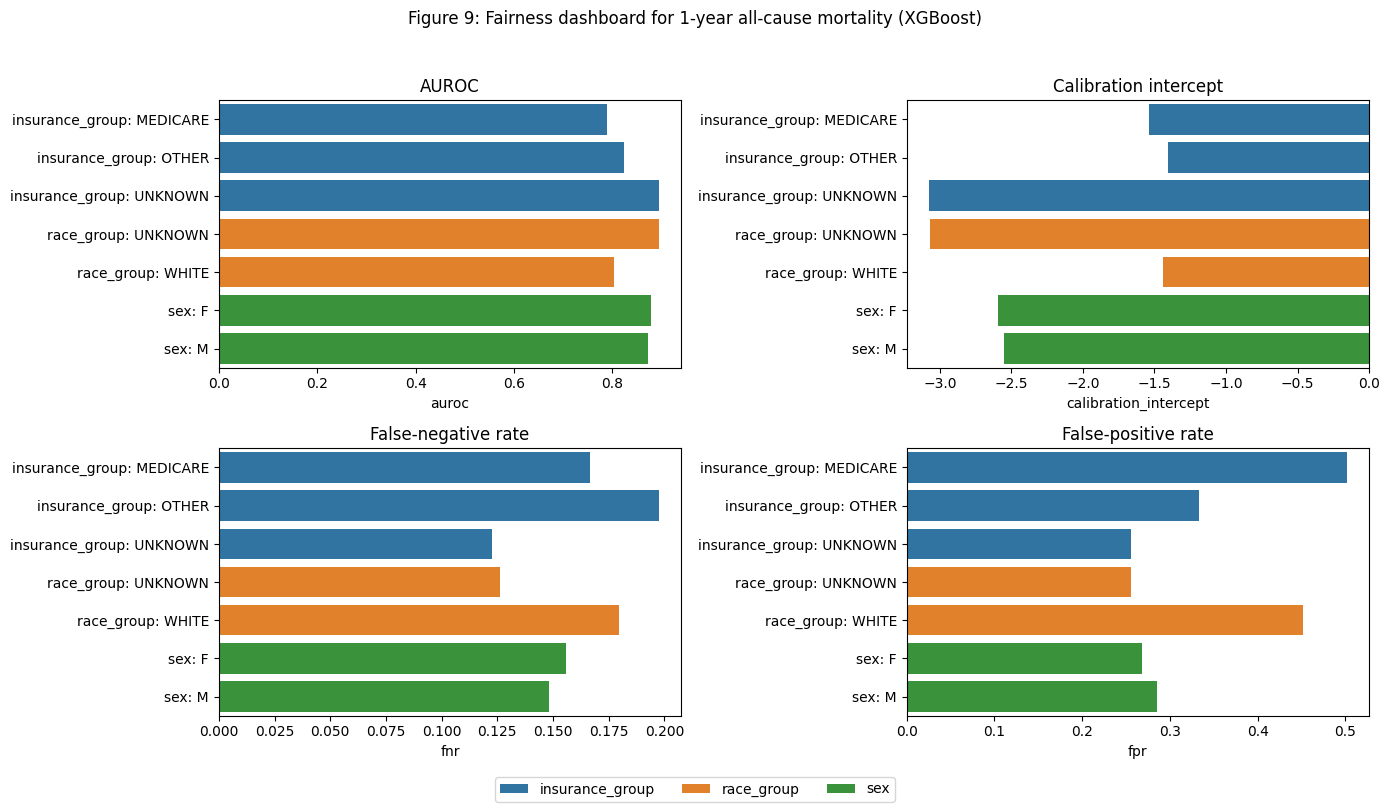

Saved: /content/outputs/paper2/figures/figure9_mortality_365_fairness_dashboard.png


In [14]:
def plot_fairness_dashboard(target_key):
    model_name = primary_models[target_key]
    plot_df = subgroup_fairness[
        subgroup_fairness["target"].eq(target_key)
        & subgroup_fairness["model"].eq(model_name)
        & subgroup_fairness["status"].eq("estimated")
    ].copy()
    if plot_df.empty:
        print("No fairness plot data for", target_key)
        return

    plot_df["group"] = plot_df["attribute"] + ": " + plot_df["level"]
    plot_df = plot_df.sort_values(["attribute", "level"])

    fig, axes = plt.subplots(2, 2, figsize=(14, max(8, len(plot_df) * 0.25)))
    metrics = [
        ("auroc", "AUROC"),
        ("calibration_intercept", "Calibration intercept"),
        ("fnr", "False-negative rate"),
        ("fpr", "False-positive rate"),
    ]
    for ax, (metric, label) in zip(axes.ravel(), metrics):
        sns.barplot(data=plot_df, y="group", x=metric, hue="attribute", dodge=False, ax=ax)
        ax.set_title(label)
        ax.set_ylabel("")
        ax.legend_.remove() if ax.legend_ else None
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)))
    fig.suptitle(f"Figure 9: Fairness dashboard for {TARGETS[target_key]['label']} ({model_name})", y=0.995)
    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    path = FIG_DIR / f"figure9_{target_key}_fairness_dashboard.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

for target_key in TARGETS:
    plot_fairness_dashboard(target_key)

## 11. Professor Comment Revision Analyses

In [15]:
# Target feasibility and anchor-year drift audit.
target_audit_rows = []
target_specs = {
    "mortality_365": {"column": "death_365", "label": "1-year all-cause mortality", "manuscript_role": "primary"},
    "cv_readmission_365": {"column": "cv_readmit_365", "label": "1-year cardiovascular readmission", "manuscript_role": "removed_after_feasibility_audit"},
}

for target_key, spec in target_specs.items():
    col = spec["column"]
    if col not in cohort.columns:
        continue
    for (split_name, group_name), sub in cohort.dropna(subset=["paper2_split", "anchor_year_group"]).groupby(["paper2_split", "anchor_year_group"]):
        y = sub[col].astype(int)
        target_audit_rows.append({
            "target": target_key,
            "target_label": spec["label"],
            "manuscript_role": spec["manuscript_role"],
            "paper2_split": split_name,
            "anchor_year_group": group_name,
            "n": int(len(sub)),
            "events": int(y.sum()),
            "event_rate": float(y.mean()),
        })

target_feasibility = pd.DataFrame(target_audit_rows)
save_table(target_feasibility, "paper2_target_feasibility_anchor_year_drift.csv")

test_cv = target_feasibility[
    target_feasibility["target"].eq("cv_readmission_365")
    & target_feasibility["paper2_split"].eq("temporal_test")
]
cv_events = int(test_cv["events"].iloc[0]) if not test_cv.empty else 0
cv_rate = float(test_cv["event_rate"].iloc[0]) if not test_cv.empty else np.nan
target_decision = pd.DataFrame([
    {
        "target": "mortality_365",
        "decision": "retain_as_primary",
        "reason": "Adequate temporal-test event count for internal temporal validation.",
    },
    {
        "target": "cv_readmission_365",
        "decision": "remove_from_primary_manuscript",
        "reason": f"Temporal-test event count is {cv_events} (event rate {cv_rate:.4f}); prediction and fairness estimates are statistically unstable.",
    },
])
save_table(target_decision, "paper2_target_feasibility_decision.csv")
display_or_print(target_feasibility.sort_values(["target", "paper2_split", "anchor_year_group"]), n=20)
display_or_print(target_decision, n=10)

Saved: /content/outputs/paper2/tables/paper2_target_feasibility_anchor_year_drift.csv
Saved: /content/outputs/paper2/tables/paper2_target_feasibility_decision.csv


,target,target_label,manuscript_role,paper2_split,anchor_year_group,n,events,event_rate
4,cv_readmission_365,1-year cardiovascular readmission,removed_after_feasibility_audit,temporal_test,2017 - 2019,4312,13,0.003015
5,cv_readmission_365,1-year cardiovascular readmission,removed_after_feasibility_audit,train_cv,2008 - 2010,8387,372,0.044354
6,cv_readmission_365,1-year cardiovascular readmission,removed_after_feasibility_audit,train_cv,2011 - 2013,5771,159,0.027552
7,cv_readmission_365,1-year cardiovascular readmission,removed_after_feasibility_audit,train_cv,2014 - 2016,5297,90,0.016991
0,mortality_365,1-year all-cause mortality,primary,temporal_test,2017 - 2019,4312,383,0.088822
1,mortality_365,1-year all-cause mortality,primary,train_cv,2008 - 2010,8387,701,0.083582
2,mortality_365,1-year all-cause mortality,primary,train_cv,2011 - 2013,5771,485,0.084041
3,mortality_365,1-year all-cause mortality,primary,train_cv,2014 - 2016,5297,498,0.094015


,target,decision,reason
0,mortality_365,retain_as_primary,Adequate temporal-test event count for interna...
1,cv_readmission_365,remove_from_primary_manuscript,Temporal-test event count is 13 (event rate 0....


In [16]:
# Additional anchor-year cohort characteristics and missingness drift audit.
# Professor comments requested cohort characteristics, event rates, and missingness across deidentified anchor-year groups.
selected_numeric_drift = [
    c for c in [
        "age_at_index", "anchor_age", "n_bp_dates", "bp_span_days", "mean_sbp", "mean_dbp",
        "sd_sbp", "vim_sbp", "cv_sbp", "simple_comorbidity_count", "antihypertensive_class_count",
        "creatinine", "sodium", "hemoglobin",
    ] if c in cohort.columns
]
selected_binary_drift = [
    c for c in ["death_365", "cv_readmit_365", "diabetes", "ckd", "heart_failure", "stroke", "icu_exposure_preindex"]
    if c in cohort.columns
]
selected_categorical_drift = [c for c in ["sex", "race_group", "insurance_group"] if c in cohort.columns]

drift_rows = []
for group_name, sub in cohort.groupby("anchor_year_group", dropna=False):
    row = {"anchor_year_group": group_name, "n": int(len(sub))}
    for col in selected_binary_drift:
        vals = pd.to_numeric(sub[col], errors="coerce")
        row[f"{col}_events"] = int(vals.fillna(0).sum())
        row[f"{col}_rate"] = float(vals.mean())
    for col in selected_numeric_drift:
        vals = pd.to_numeric(sub[col], errors="coerce")
        row[f"{col}_mean"] = float(vals.mean())
        row[f"{col}_sd"] = float(vals.std())
        row[f"{col}_missing_fraction"] = float(vals.isna().mean())
    for col in selected_categorical_drift:
        counts = sub[col].astype("string").fillna("MISSING").value_counts(normalize=True)
        row[f"{col}_top_level"] = str(counts.index[0]) if len(counts) else ""
        row[f"{col}_top_level_fraction"] = float(counts.iloc[0]) if len(counts) else np.nan
        row[f"{col}_missing_fraction"] = float(sub[col].isna().mean())
    drift_rows.append(row)

anchor_year_characteristics = pd.DataFrame(drift_rows).sort_values("anchor_year_group")
save_table(anchor_year_characteristics, "paper2_anchor_year_group_characteristics.csv")

missingness_by_anchor_rows = []
for group_name, sub in cohort.groupby("anchor_year_group", dropna=False):
    for col in feature_cols:
        missingness_by_anchor_rows.append({
            "anchor_year_group": group_name,
            "variable": col,
            "missing_fraction": float(sub[col].isna().mean()),
            "n": int(len(sub)),
        })
anchor_year_missingness = pd.DataFrame(missingness_by_anchor_rows)
save_table(anchor_year_missingness, "paper2_anchor_year_group_feature_missingness.csv")

display_or_print(anchor_year_characteristics, n=10)
display_or_print(anchor_year_missingness, n=40)


Saved: /content/outputs/paper2/tables/paper2_anchor_year_group_characteristics.csv
Saved: /content/outputs/paper2/tables/paper2_anchor_year_group_feature_missingness.csv


,anchor_year_group,n,death_365_events,death_365_rate,cv_readmit_365_events,cv_readmit_365_rate,diabetes_events,diabetes_rate,ckd_events,ckd_rate,...,hemoglobin_missing_fraction,sex_top_level,sex_top_level_fraction,sex_missing_fraction,race_group_top_level,race_group_top_level_fraction,race_group_missing_fraction,insurance_group_top_level,insurance_group_top_level_fraction,insurance_group_missing_fraction
0,2008 - 2010,8387,701,0.083582,372,0.044354,2865,0.341600,1442,0.171933,...,0.000835,F,0.572910,0.0,WHITE,0.384524,0.0,MEDICARE,0.358531,0.0
1,2011 - 2013,5771,485,0.084041,159,0.027552,1818,0.315023,859,0.148848,...,0.002253,F,0.518628,0.0,UNKNOWN,0.455380,0.0,UNKNOWN,0.454687,0.0
2,2014 - 2016,5297,498,0.094015,90,0.016991,1665,0.314329,858,0.161978,...,0.003587,M,0.515008,0.0,UNKNOWN,0.578818,0.0,UNKNOWN,0.577119,0.0
3,2017 - 2019,4312,383,0.088822,13,0.003015,1371,0.317950,736,0.170686,...,0.002551,M,0.526438,0.0,UNKNOWN,0.832560,0.0,UNKNOWN,0.830937,0.0


,anchor_year_group,variable,missing_fraction,n
0,2008 - 2010,age_at_index,0.000000,8387
1,2008 - 2010,anchor_age,0.000000,8387
2,2008 - 2010,anchor_year,0.000000,8387
3,2008 - 2010,n_bp_dates,0.000000,8387
4,2008 - 2010,bp_span_days,0.000000,8387
5,2008 - 2010,mean_sbp,0.000000,8387
6,2008 - 2010,mean_dbp,0.000000,8387
7,2008 - 2010,sd_sbp,0.000000,8387
8,2008 - 2010,sd_dbp,0.000000,8387
9,2008 - 2010,arv_sbp,0.000000,8387


In [17]:
# Operational predictor definitions required by TRIPOD Item 8b.
def predictor_definition(variable):
    v = str(variable)
    exact = {
        "age_at_index": ("demographics", "Age at BPV index date.", "Continuous years."),
        "anchor_age": ("MIMIC-IV patients", "Deidentified age anchor available in MIMIC-IV.", "Continuous years."),
        "anchor_year": ("MIMIC-IV patients", "Deidentified anchor year.", "Continuous year value."),
        "sex": ("MIMIC-IV patients", "Recorded administrative sex.", "Categorical."),
        "race_group": ("MIMIC-IV admissions/patients", "Collapsed race category; UNKNOWN is a missingness/documentation group.", "Categorical."),
        "insurance_group": ("MIMIC-IV admissions", "Collapsed insurance category at index admission.", "Categorical."),
        "bpv_q": ("derived OMR blood-pressure series", "Quartile of the primary BPV metric.", "Categorical quartile."),
        "anchor_year_group": ("MIMIC-IV patients", "Grouped deidentified anchor year used for train/test split.", "Categorical calendar group."),
        "n_bp_dates": ("derived OMR blood-pressure series", "Number of distinct dates with eligible blood-pressure measurements before index.", "Count."),
        "bp_span_days": ("derived OMR blood-pressure series", "Calendar span between first and last eligible BP date.", "Days."),
        "mean_sbp": ("derived OMR blood-pressure series", "Mean pre-index systolic blood pressure.", "mm Hg."),
        "mean_dbp": ("derived OMR blood-pressure series", "Mean pre-index diastolic blood pressure.", "mm Hg."),
        "sd_sbp": ("derived OMR blood-pressure series", "Visit-to-visit standard deviation of systolic BP.", "mm Hg."),
        "sd_dbp": ("derived OMR blood-pressure series", "Visit-to-visit standard deviation of diastolic BP.", "mm Hg."),
        "arv_sbp": ("derived OMR blood-pressure series", "Average real variability for systolic BP across ordered visits.", "mm Hg."),
        "arv_dbp": ("derived OMR blood-pressure series", "Average real variability for diastolic BP across ordered visits.", "mm Hg."),
        "vim_sbp": ("derived OMR blood-pressure series", "Variability independent of the mean for systolic BP.", "Unitless transformed BPV."),
        "vim_dbp": ("derived OMR blood-pressure series", "Variability independent of the mean for diastolic BP.", "Unitless transformed BPV."),
        "cv_sbp": ("derived OMR blood-pressure series", "Coefficient of variation for systolic BP.", "Percent/ratio."),
        "cv_dbp": ("derived OMR blood-pressure series", "Coefficient of variation for diastolic BP.", "Percent/ratio."),
        "bpv_z": ("derived OMR blood-pressure series", "Standardized composite BPV score.", "Z score."),
        "icu_exposure_preindex": ("MIMIC-IV ICU stays", "Any ICU exposure before BPV index.", "Binary indicator."),
        "simple_comorbidity_count": ("MIMIC-IV diagnoses", "Count of coded comorbidity flags present before index.", "Count."),
        "antihypertensive_class_count": ("MIMIC-IV medication records", "Number of antihypertensive medication classes identified before index.", "Count."),
    }
    if v in exact:
        return exact[v]
    if v in {"bmi", "height", "weight"}:
        return ("MIMIC-IV chart/OMR-derived anthropometrics", f"Baseline {v.replace('_', ' ')} closest to the pre-index window.", "Continuous.")
    if v in {"creatinine", "potassium", "sodium", "glucose", "hba1c", "hdl", "ldl", "total_cholesterol", "hemoglobin"}:
        return ("MIMIC-IV laboratory events", f"Baseline/pre-index {v.replace('_', ' ')} value.", "Continuous; median-imputed inside training folds.")
    if v in {"diabetes", "ckd", "heart_failure", "prior_mi", "stroke", "atrial_fibrillation", "copd"}:
        return ("MIMIC-IV ICD diagnosis codes", f"Pre-index diagnosis flag for {v.replace('_', ' ')}.", "Binary indicator.")
    if v in {"acei_arb", "diuretic", "ccb", "beta_blocker", "other_antihypertensive", "statin", "antiplatelet_anticoagulant"}:
        return ("MIMIC-IV medication records", f"Pre-index medication class indicator for {v.replace('_', ' ')}.", "Binary indicator.")
    return ("source analytic cohort", f"Predictor retained from source cohort: {v}.", "See cohort construction code.")

operational_rows = []
for _, row in feature_dictionary[feature_dictionary["role"].str.contains("predictor", na=False)].iterrows():
    source, definition, coding = predictor_definition(row["variable"])
    operational_rows.append({
        "variable": row["variable"],
        "role": row["role"],
        "source_or_table": source,
        "operational_definition": definition,
        "coding_rule": coding,
        "missing_fraction": row.get("missing_fraction", np.nan),
    })

operational_definitions = pd.DataFrame(operational_rows)
save_table(operational_definitions, "paper2_predictor_operational_definitions.csv")
display_or_print(operational_definitions, n=80)

Saved: /content/outputs/paper2/tables/paper2_predictor_operational_definitions.csv


,variable,role,source_or_table,operational_definition,coding_rule,missing_fraction
0,age_at_index,numeric_predictor,demographics,Age at BPV index date.,Continuous years.,0.000000
1,anchor_age,numeric_predictor,MIMIC-IV patients,Deidentified age anchor available in MIMIC-IV.,Continuous years.,0.000000
2,anchor_year,numeric_predictor,MIMIC-IV patients,Deidentified anchor year.,Continuous year value.,0.000000
3,n_bp_dates,numeric_predictor,derived OMR blood-pressure series,Number of distinct dates with eligible blood-p...,Count.,0.000000
4,bp_span_days,numeric_predictor,derived OMR blood-pressure series,Calendar span between first and last eligible ...,Days.,0.000000
5,mean_sbp,numeric_predictor,derived OMR blood-pressure series,Mean pre-index systolic blood pressure.,mm Hg.,0.000000
6,mean_dbp,numeric_predictor,derived OMR blood-pressure series,Mean pre-index diastolic blood pressure.,mm Hg.,0.000000
7,sd_sbp,numeric_predictor,derived OMR blood-pressure series,Visit-to-visit standard deviation of systolic BP.,mm Hg.,0.000000
8,sd_dbp,numeric_predictor,derived OMR blood-pressure series,Visit-to-visit standard deviation of diastolic...,mm Hg.,0.000000
9,arv_sbp,numeric_predictor,derived OMR blood-pressure series,Average real variability for systolic BP acros...,mm Hg.,0.000000


Saved: /content/outputs/paper2/tables/paper2_temporal_test_metric_intervals.csv
Saved: /content/outputs/paper2/tables/paper2_pairwise_model_comparisons_temporal_test.csv
Saved: /content/outputs/paper2/tables/paper2_mortality_primary_calibration_deciles.csv


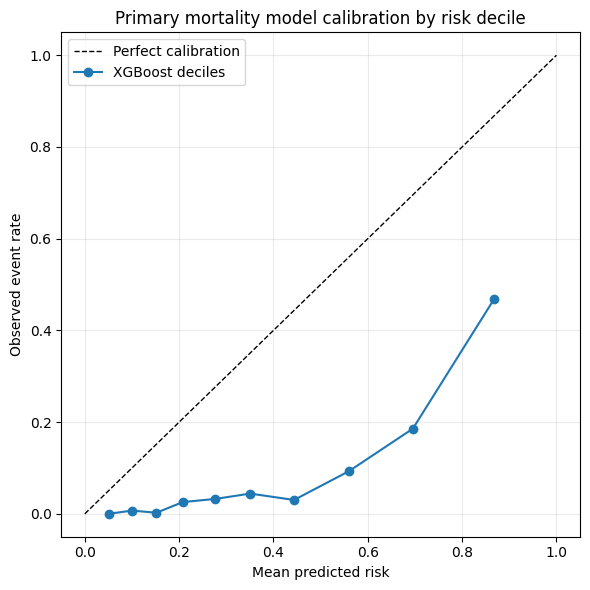

Saved: /content/outputs/paper2/figures/figure10_mortality_primary_calibration_deciles.png


,target,model,metric,estimate,ci_95_low,ci_95_high,method
0,mortality_365,ElasticNetLogistic,auroc,0.822156,0.799571,0.843640,patient-level nonparametric bootstrap on tempo...
1,mortality_365,ElasticNetLogistic,auprc,0.340263,0.297284,0.393359,patient-level nonparametric bootstrap on tempo...
2,mortality_365,ElasticNetLogistic,brier,0.110237,0.103932,0.116026,patient-level nonparametric bootstrap on tempo...
3,mortality_365,ElasticNetLogistic,calibration_intercept,-1.771953,-1.902310,-1.647169,patient-level nonparametric bootstrap on tempo...
4,mortality_365,ElasticNetLogistic,calibration_slope,0.485019,0.419340,0.556975,patient-level nonparametric bootstrap on tempo...
5,mortality_365,RandomForest,auroc,0.859937,0.840234,0.878730,patient-level nonparametric bootstrap on tempo...
6,mortality_365,RandomForest,auprc,0.467933,0.417106,0.521393,patient-level nonparametric bootstrap on tempo...
7,mortality_365,RandomForest,brier,0.116880,0.113252,0.120658,patient-level nonparametric bootstrap on tempo...
8,mortality_365,RandomForest,calibration_intercept,-1.651231,-1.774972,-1.535706,patient-level nonparametric bootstrap on tempo...
9,mortality_365,RandomForest,calibration_slope,1.709752,1.559390,1.876714,patient-level nonparametric bootstrap on tempo...


,target,metric,model_a,model_b,difference_a_minus_b,ci_95_low,ci_95_high,bootstrap_p_value,method
0,mortality_365,auroc,ElasticNetLogistic,RandomForest,-0.037781,-0.054792,-0.023502,0.0,paired patient-level bootstrap on temporal-tes...
1,mortality_365,auprc,ElasticNetLogistic,RandomForest,-0.127669,-0.165103,-0.084085,0.0,paired patient-level bootstrap on temporal-tes...
2,mortality_365,auroc,ElasticNetLogistic,XGBoost,-0.053550,-0.070649,-0.038020,0.0,paired patient-level bootstrap on temporal-tes...
3,mortality_365,auprc,ElasticNetLogistic,XGBoost,-0.172503,-0.215258,-0.126959,0.0,paired patient-level bootstrap on temporal-tes...
4,mortality_365,auroc,RandomForest,XGBoost,-0.015769,-0.024640,-0.007129,0.0,paired patient-level bootstrap on temporal-tes...
5,mortality_365,auprc,RandomForest,XGBoost,-0.044834,-0.071630,-0.018040,0.0,paired patient-level bootstrap on temporal-tes...


,risk_decile,n,events,mean_predicted_risk,observed_event_rate
0,D1,432,0,0.050307,0.000000
1,D2,431,3,0.100134,0.006961
2,D3,431,1,0.151788,0.002320
3,D4,431,11,0.207530,0.025522
4,D5,431,14,0.276988,0.032483
5,D6,431,19,0.350672,0.044084
6,D7,431,13,0.443638,0.030162
7,D8,431,40,0.559787,0.092807
8,D9,431,80,0.695506,0.185615
9,D10,432,202,0.867430,0.467593


In [18]:
# Bootstrap confidence intervals and paired model comparisons for temporal-test metrics.
BOOTSTRAP_ITERATIONS = 1000
BOOTSTRAP_RANDOM_STATE = 20260601

def metric_value(metric, y, p):
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    if len(np.unique(y)) < 2 and metric in {"auroc", "auprc", "calibration_intercept", "calibration_slope"}:
        return np.nan
    if metric == "auroc":
        return safe_auc(y, p)
    if metric == "auprc":
        return safe_auprc(y, p)
    if metric == "brier":
        return brier_score_loss(y, p)
    if metric == "calibration_intercept":
        return calibration_intercept_slope(y, p)[0]
    if metric == "calibration_slope":
        return calibration_intercept_slope(y, p)[1]
    raise ValueError(metric)

def bootstrap_ci_metric(y, p, metric, n_boot=BOOTSTRAP_ITERATIONS):
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        val = metric_value(metric, y[idx], p[idx])
        if np.isfinite(val):
            vals.append(val)
    if not vals:
        return np.nan, np.nan
    return tuple(np.percentile(vals, [2.5, 97.5]))

interval_rows = []
for (target_key, model_name), sub in prediction_test.groupby(["target", "model"]):
    y = sub["y_true"].astype(int).values
    p = sub["predicted_risk"].astype(float).values
    for metric in ["auroc", "auprc", "brier", "calibration_intercept", "calibration_slope"]:
        estimate = metric_value(metric, y, p)
        low, high = bootstrap_ci_metric(y, p, metric)
        interval_rows.append({
            "target": target_key,
            "model": model_name,
            "metric": metric,
            "estimate": estimate,
            "ci_95_low": low,
            "ci_95_high": high,
            "method": "patient-level nonparametric bootstrap on temporal-test predictions",
        })

metric_intervals = pd.DataFrame(interval_rows)
save_table(metric_intervals, "paper2_temporal_test_metric_intervals.csv")

comparison_rows = []
for target_key, target_pred in prediction_test.groupby("target"):
    model_names = sorted(target_pred["model"].unique())
    wide = target_pred.pivot_table(
        index=target_pred.groupby("model").cumcount(),
        columns="model",
        values="predicted_risk",
        aggfunc="first",
    )
    y = target_pred[target_pred["model"].eq(model_names[0])]["y_true"].astype(int).values
    for model_a, model_b in itertools.combinations(model_names, 2):
        for metric in ["auroc", "auprc"]:
            p_a = wide[model_a].astype(float).values
            p_b = wide[model_b].astype(float).values
            observed = metric_value(metric, y, p_a) - metric_value(metric, y, p_b)
            rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
            diffs = []
            for _ in range(BOOTSTRAP_ITERATIONS):
                idx = rng.integers(0, len(y), len(y))
                if len(np.unique(y[idx])) < 2:
                    continue
                diffs.append(metric_value(metric, y[idx], p_a[idx]) - metric_value(metric, y[idx], p_b[idx]))
            if diffs:
                low, high = np.percentile(diffs, [2.5, 97.5])
                p_value = 2 * min(np.mean(np.asarray(diffs) <= 0), np.mean(np.asarray(diffs) >= 0))
            else:
                low, high, p_value = np.nan, np.nan, np.nan
            comparison_rows.append({
                "target": target_key,
                "metric": metric,
                "model_a": model_a,
                "model_b": model_b,
                "difference_a_minus_b": observed,
                "ci_95_low": low,
                "ci_95_high": high,
                "bootstrap_p_value": p_value,
                "method": "paired patient-level bootstrap on temporal-test predictions",
            })

model_comparisons = pd.DataFrame(comparison_rows)
save_table(model_comparisons, "paper2_pairwise_model_comparisons_temporal_test.csv")

# Dedicated decile calibration plot for the primary mortality model.
mortality_model = primary_models.get("mortality_365")
mortality_pred = prediction_test[
    prediction_test["target"].eq("mortality_365")
    & prediction_test["model"].eq(mortality_model)
].copy()
mortality_pred["risk_decile"] = pd.qcut(
    mortality_pred["predicted_risk"].rank(method="first"),
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
)
calibration_deciles = (
    mortality_pred.groupby("risk_decile", observed=False)
    .agg(
        n=("y_true", "size"),
        events=("y_true", "sum"),
        mean_predicted_risk=("predicted_risk", "mean"),
        observed_event_rate=("y_true", "mean"),
    )
    .reset_index()
)
save_table(calibration_deciles, "paper2_mortality_primary_calibration_deciles.csv")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color="black", lw=1, ls="--", label="Perfect calibration")
ax.plot(
    calibration_deciles["mean_predicted_risk"],
    calibration_deciles["observed_event_rate"],
    marker="o",
    color="#1F77B4",
    label=f"{mortality_model} deciles",
)
ax.set_xlabel("Mean predicted risk")
ax.set_ylabel("Observed event rate")
ax.set_title("Primary mortality model calibration by risk decile")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
calibration_path = FIG_DIR / "figure10_mortality_primary_calibration_deciles.png"
fig.savefig(calibration_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", calibration_path)

display_or_print(metric_intervals, n=40)
display_or_print(model_comparisons, n=40)
display_or_print(calibration_deciles, n=20)

In [19]:
# Additional CI outputs requested for Tables 3, 5, 7, and 8.
# Table 3: approximate 95% intervals from CV means/SDs already computed in the modeling cell.
cv_interval_rows = []
for _, row in cv_performance.iterrows():
    folds = float(row.get("actual_folds", REQUESTED_CV_FOLDS))
    for metric, mean_col, sd_col in [
        ("auroc", "cv_auroc_mean", "cv_auroc_sd"),
        ("auprc", "cv_auprc_mean", "cv_auprc_sd"),
        ("brier", "cv_brier_mean", "cv_brier_sd"),
    ]:
        mean = float(row[mean_col])
        sd = float(row[sd_col])
        se = sd / np.sqrt(folds) if np.isfinite(sd) and folds > 0 else np.nan
        cv_interval_rows.append({
            "target": row["target"],
            "model": row["model"],
            "metric": metric,
            "folds": int(folds),
            "estimate": mean,
            "ci_95_low": mean - 1.96 * se if np.isfinite(se) else np.nan,
            "ci_95_high": mean + 1.96 * se if np.isfinite(se) else np.nan,
            "method": "normal approximation using cross-validation mean and SD",
        })
cv_metric_intervals = pd.DataFrame(cv_interval_rows)
save_table(cv_metric_intervals, "paper2_cv_metric_intervals_train.csv")


def bootstrap_ci_threshold_metric(y, p, threshold, metric, n_boot=BOOTSTRAP_ITERATIONS, seed=BOOTSTRAP_RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        val = threshold_metrics(y[idx], p[idx], threshold).get(metric, np.nan)
        if np.isfinite(val):
            vals.append(val)
    if not vals:
        return np.nan, np.nan
    return tuple(np.percentile(vals, [2.5, 97.5]))


threshold_interval_rows = []
for target_key, model_name in primary_models.items():
    target_col = TARGETS[target_key]["column"]
    model_data = cohort.dropna(subset=[target_col, "paper2_split"]).copy()
    train_mask = model_data["paper2_split"].eq("train_cv")
    test_mask = model_data["paper2_split"].eq("temporal_test")
    for split_name, mask in [("train_cv_refit", train_mask), ("temporal_test", test_mask)]:
        X_eval = model_data.loc[mask, feature_cols].copy()
        y_eval = model_data.loc[mask, target_col].astype(int).values
        pipe = fitted_models[target_key][model_name]
        p_eval = predict_proba_positive(pipe, X_eval)
        threshold = float(
            thresholds_table[
                thresholds_table["target"].eq(target_key) & thresholds_table["model"].eq(model_name)
            ]["threshold"].iloc[0]
        )
        point = threshold_metrics(y_eval, p_eval, threshold)
        for metric in ["sensitivity_tpr", "specificity_tnr", "ppv", "npv", "fpr", "fnr"]:
            low, high = bootstrap_ci_threshold_metric(y_eval, p_eval, threshold, metric)
            threshold_interval_rows.append({
                "target": target_key,
                "model": model_name,
                "split": split_name,
                "threshold": threshold,
                "metric": metric,
                "estimate": point.get(metric, np.nan),
                "ci_95_low": low,
                "ci_95_high": high,
                "method": "patient-level bootstrap at full-training-refit Youden threshold",
            })
threshold_metric_intervals = pd.DataFrame(threshold_interval_rows)
save_table(threshold_metric_intervals, "paper2_threshold_metric_intervals.csv")

# Recompute pairwise comparisons with explicit row/subject alignment.
def align_pairwise_predictions(target_pred, model_a, model_b):
    if "subject_id" in target_pred.columns and target_pred["subject_id"].notna().all():
        key_cols = ["subject_id"]
    else:
        target_pred = target_pred.copy()
        target_pred["_row_order"] = target_pred.groupby("model").cumcount()
        key_cols = ["_row_order"]
    a = target_pred[target_pred["model"].eq(model_a)][key_cols + ["y_true", "predicted_risk"]].rename(
        columns={"y_true": "y_true_a", "predicted_risk": "p_a"}
    )
    b = target_pred[target_pred["model"].eq(model_b)][key_cols + ["y_true", "predicted_risk"]].rename(
        columns={"y_true": "y_true_b", "predicted_risk": "p_b"}
    )
    merged = a.merge(b, on=key_cols, how="inner")
    return merged["y_true_a"].astype(int).values, merged["p_a"].astype(float).values, merged["p_b"].astype(float).values

aligned_comparison_rows = []
for target_key, target_pred in prediction_test.groupby("target"):
    model_names = sorted(target_pred["model"].unique())
    for model_a, model_b in itertools.combinations(model_names, 2):
        y, p_a, p_b = align_pairwise_predictions(target_pred, model_a, model_b)
        for metric in ["auroc", "auprc"]:
            observed = metric_value(metric, y, p_a) - metric_value(metric, y, p_b)
            rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
            diffs = []
            for _ in range(BOOTSTRAP_ITERATIONS):
                idx = rng.integers(0, len(y), len(y))
                if len(np.unique(y[idx])) < 2:
                    continue
                diffs.append(metric_value(metric, y[idx], p_a[idx]) - metric_value(metric, y[idx], p_b[idx]))
            if diffs:
                diffs = np.asarray(diffs)
                low, high = np.percentile(diffs, [2.5, 97.5])
                p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
            else:
                low, high, p_value = np.nan, np.nan, np.nan
            aligned_comparison_rows.append({
                "target": target_key,
                "metric": metric,
                "model_a": model_a,
                "model_b": model_b,
                "difference_a_minus_b": observed,
                "ci_95_low": low,
                "ci_95_high": high,
                "bootstrap_p_value": min(float(p_value), 1.0) if np.isfinite(p_value) else np.nan,
                "method": "paired patient-level bootstrap with explicit prediction alignment",
            })
model_comparisons_aligned = pd.DataFrame(aligned_comparison_rows)
save_table(model_comparisons_aligned, "paper2_pairwise_model_comparisons_temporal_test_aligned.csv")

subgroup_interval_rows = []
if "subgroup_fairness" in globals() and not subgroup_fairness.empty:
    estimated = subgroup_fairness[subgroup_fairness["status"].eq("estimated")].copy()
    for _, row in estimated.iterrows():
        target_key = row["target"]
        model_name = row["model"]
        attr = row["attribute"]
        level = row["level"]
        pred_sub = prediction_test[
            prediction_test["target"].eq(target_key)
            & prediction_test["model"].eq(model_name)
            & prediction_test[attr].astype(str).eq(str(level))
        ].copy()
        if pred_sub.empty:
            continue
        y = pred_sub["y_true"].astype(int).values
        p = pred_sub["predicted_risk"].astype(float).values
        threshold = float(pred_sub["threshold"].iloc[0])
        for metric in ["auroc", "auprc", "brier", "calibration_intercept", "calibration_slope"]:
            low, high = bootstrap_ci_metric(y, p, metric)
            subgroup_interval_rows.append({
                "target": target_key,
                "model": model_name,
                "attribute": attr,
                "level": level,
                "metric": metric,
                "estimate": metric_value(metric, y, p),
                "ci_95_low": low,
                "ci_95_high": high,
                "method": "patient-level bootstrap within subgroup",
            })
        point = threshold_metrics(y, p, threshold)
        for metric in ["sensitivity_tpr", "specificity_tnr", "ppv", "npv", "fpr", "fnr"]:
            low, high = bootstrap_ci_threshold_metric(y, p, threshold, metric)
            subgroup_interval_rows.append({
                "target": target_key,
                "model": model_name,
                "attribute": attr,
                "level": level,
                "metric": metric,
                "estimate": point.get(metric, np.nan),
                "ci_95_low": low,
                "ci_95_high": high,
                "method": "patient-level bootstrap within subgroup",
            })
subgroup_metric_intervals = pd.DataFrame(subgroup_interval_rows)
save_table(subgroup_metric_intervals, "paper2_subgroup_metric_intervals.csv")

display_or_print(cv_metric_intervals, n=30)
display_or_print(threshold_metric_intervals, n=40)
display_or_print(model_comparisons_aligned, n=40)
display_or_print(subgroup_metric_intervals, n=60)


Saved: /content/outputs/paper2/tables/paper2_cv_metric_intervals_train.csv
Saved: /content/outputs/paper2/tables/paper2_threshold_metric_intervals.csv
Saved: /content/outputs/paper2/tables/paper2_pairwise_model_comparisons_temporal_test_aligned.csv
Saved: /content/outputs/paper2/tables/paper2_subgroup_metric_intervals.csv


,target,model,metric,folds,estimate,ci_95_low,ci_95_high,method
0,mortality_365,ElasticNetLogistic,auroc,10,0.813642,0.793346,0.833937,normal approximation using cross-validation me...
1,mortality_365,ElasticNetLogistic,auprc,10,0.312305,0.274433,0.350177,normal approximation using cross-validation me...
2,mortality_365,ElasticNetLogistic,brier,10,0.173472,0.149343,0.197601,normal approximation using cross-validation me...
3,mortality_365,RandomForest,auroc,10,0.868470,0.860541,0.876399,normal approximation using cross-validation me...
4,mortality_365,RandomForest,auprc,10,0.452509,0.426035,0.478982,normal approximation using cross-validation me...
5,mortality_365,RandomForest,brier,10,0.101543,0.100153,0.102934,normal approximation using cross-validation me...
6,mortality_365,XGBoost,auroc,10,0.882699,0.876192,0.889205,normal approximation using cross-validation me...
7,mortality_365,XGBoost,auprc,10,0.514718,0.489196,0.540241,normal approximation using cross-validation me...
8,mortality_365,XGBoost,brier,10,0.126830,0.125673,0.127986,normal approximation using cross-validation me...


,target,model,split,threshold,metric,estimate,ci_95_low,ci_95_high,method
0,mortality_365,XGBoost,train_cv_refit,0.465561,sensitivity_tpr,0.875891,0.860298,0.890642,patient-level bootstrap at full-training-refit...
1,mortality_365,XGBoost,train_cv_refit,0.465561,specificity_tnr,0.807327,0.801471,0.813164,patient-level bootstrap at full-training-refit...
2,mortality_365,XGBoost,train_cv_refit,0.465561,ppv,0.301082,0.288802,0.314962,patient-level bootstrap at full-training-refit...
3,mortality_365,XGBoost,train_cv_refit,0.465561,npv,0.985642,0.983777,0.987488,patient-level bootstrap at full-training-refit...
4,mortality_365,XGBoost,train_cv_refit,0.465561,fpr,0.192673,0.186836,0.198529,patient-level bootstrap at full-training-refit...
5,mortality_365,XGBoost,train_cv_refit,0.465561,fnr,0.124109,0.109358,0.139702,patient-level bootstrap at full-training-refit...
6,mortality_365,XGBoost,temporal_test,0.465561,sensitivity_tpr,0.848564,0.810957,0.884618,patient-level bootstrap at full-training-refit...
7,mortality_365,XGBoost,temporal_test,0.465561,specificity_tnr,0.722830,0.708651,0.736359,patient-level bootstrap at full-training-refit...
8,mortality_365,XGBoost,temporal_test,0.465561,ppv,0.229844,0.206648,0.251945,patient-level bootstrap at full-training-refit...
9,mortality_365,XGBoost,temporal_test,0.465561,npv,0.979986,0.974963,0.985080,patient-level bootstrap at full-training-refit...


,target,metric,model_a,model_b,difference_a_minus_b,ci_95_low,ci_95_high,bootstrap_p_value,method
0,mortality_365,auroc,ElasticNetLogistic,RandomForest,-0.037781,-0.054792,-0.023502,0.0,paired patient-level bootstrap with explicit p...
1,mortality_365,auprc,ElasticNetLogistic,RandomForest,-0.127669,-0.165103,-0.084085,0.0,paired patient-level bootstrap with explicit p...
2,mortality_365,auroc,ElasticNetLogistic,XGBoost,-0.053550,-0.070649,-0.038020,0.0,paired patient-level bootstrap with explicit p...
3,mortality_365,auprc,ElasticNetLogistic,XGBoost,-0.172503,-0.215258,-0.126959,0.0,paired patient-level bootstrap with explicit p...
4,mortality_365,auroc,RandomForest,XGBoost,-0.015769,-0.024640,-0.007129,0.0,paired patient-level bootstrap with explicit p...
5,mortality_365,auprc,RandomForest,XGBoost,-0.044834,-0.071630,-0.018040,0.0,paired patient-level bootstrap with explicit p...


,target,model,attribute,level,metric,estimate,ci_95_low,ci_95_high,method
0,mortality_365,XGBoost,race_group,UNKNOWN,auroc,0.894611,0.874845,0.913209,patient-level bootstrap within subgroup
1,mortality_365,XGBoost,race_group,UNKNOWN,auprc,0.436254,0.367210,0.506755,patient-level bootstrap within subgroup
2,mortality_365,XGBoost,race_group,UNKNOWN,brier,0.153648,0.147777,0.160400,patient-level bootstrap within subgroup
3,mortality_365,XGBoost,race_group,UNKNOWN,calibration_intercept,-3.066588,-3.296572,-2.889232,patient-level bootstrap within subgroup
4,mortality_365,XGBoost,race_group,UNKNOWN,calibration_slope,1.304154,1.182847,1.448172,patient-level bootstrap within subgroup
5,mortality_365,XGBoost,race_group,UNKNOWN,sensitivity_tpr,0.873737,0.828406,0.917959,patient-level bootstrap within subgroup
6,mortality_365,XGBoost,race_group,UNKNOWN,specificity_tnr,0.744399,0.729481,0.758926,patient-level bootstrap within subgroup
7,mortality_365,XGBoost,race_group,UNKNOWN,ppv,0.166346,0.143692,0.187621,patient-level bootstrap within subgroup
8,mortality_365,XGBoost,race_group,UNKNOWN,npv,0.990196,0.986533,0.993701,patient-level bootstrap within subgroup
9,mortality_365,XGBoost,race_group,UNKNOWN,fpr,0.255601,0.241074,0.270519,patient-level bootstrap within subgroup


In [20]:
# Sensitivity analyses: BPV-feature contribution and healthcare-utilization-feature dominance.
target_key = "mortality_365"
target_col = TARGETS[target_key]["column"]
primary_model_name = primary_models[target_key]
base_model_specs = make_model_specs(cohort.loc[cohort["paper2_split"].eq("train_cv"), target_col].astype(int).values)

BPV_FEATURES = [
    "sd_sbp", "sd_dbp", "arv_sbp", "arv_dbp", "vim_sbp", "vim_dbp",
    "cv_sbp", "cv_dbp", "bpv_z", "bpv_q",
]
UTILIZATION_FEATURES = ["n_bp_dates", "bp_span_days"]

def make_subset_pipeline(estimator, selected_features):
    selected_numeric = [c for c in numeric_features if c in selected_features]
    selected_categorical = [c for c in categorical_features if c in selected_features]
    transformers = []
    if selected_numeric:
        transformers.append((
            "num",
            Pipeline(steps=[("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
            selected_numeric,
        ))
    if selected_categorical:
        transformers.append((
            "cat",
            Pipeline(steps=[("impute", SimpleImputer(strategy="most_frequent")), ("onehot", make_onehot_encoder())]),
            selected_categorical,
        ))
    return Pipeline(steps=[("preprocess", ColumnTransformer(transformers=transformers)), ("model", estimator)])

def evaluate_feature_set(name, excluded):
    selected = [c for c in feature_cols if c not in set(excluded)]
    model_data = cohort.dropna(subset=[target_col, "paper2_split"]).copy()
    train_mask = model_data["paper2_split"].eq("train_cv")
    test_mask = model_data["paper2_split"].eq("temporal_test")
    X_train = model_data.loc[train_mask, selected].copy()
    y_train = model_data.loc[train_mask, target_col].astype(int).copy()
    X_test = model_data.loc[test_mask, selected].copy()
    y_test = model_data.loc[test_mask, target_col].astype(int).copy()
    estimator = clone(base_model_specs[primary_model_name])
    pipe = make_subset_pipeline(estimator, selected)
    pipe.fit(X_train, y_train)
    p_test = predict_proba_positive(pipe, X_test)
    threshold = choose_threshold_youden(y_train, predict_proba_positive(pipe, X_train))
    row = metric_row(y_test, p_test, TARGETS[target_key]["label"], target_key, primary_model_name, name)
    row.update({
        "feature_set": name,
        "n_features": len(selected),
        "excluded_features": "; ".join([c for c in excluded if c in feature_cols]),
        "threshold": threshold,
    })
    return row

sensitivity_rows = []
sensitivity_rows.append(evaluate_feature_set("full_feature_refit", []))
sensitivity_rows.append(evaluate_feature_set("exclude_bpv_metrics", BPV_FEATURES))
sensitivity_rows.append(evaluate_feature_set("exclude_bp_observation_intensity", UTILIZATION_FEATURES))
sensitivity_rows.append(evaluate_feature_set("exclude_bpv_and_observation_intensity", BPV_FEATURES + UTILIZATION_FEATURES))
sensitivity = pd.DataFrame(sensitivity_rows)
full = sensitivity.loc[sensitivity["feature_set"].eq("full_feature_refit")].iloc[0]
for metric in ["auroc", "auprc", "brier", "calibration_intercept", "calibration_slope"]:
    sensitivity[f"delta_{metric}_vs_full"] = sensitivity[metric] - full[metric]

save_table(sensitivity, "paper2_mortality_feature_set_sensitivity.csv")
display_or_print(sensitivity, n=10)

Saved: /content/outputs/paper2/tables/paper2_mortality_feature_set_sensitivity.csv


,target,target_label,model,split,n,events,event_rate,auroc,auprc,brier,...,calibration_slope,feature_set,n_features,excluded_features,threshold,delta_auroc_vs_full,delta_auprc_vs_full,delta_brier_vs_full,delta_calibration_intercept_vs_full,delta_calibration_slope_vs_full
0,mortality_365,1-year all-cause mortality,XGBoost,full_feature_refit,4312,383,0.088822,0.875706,0.512767,0.163332,...,1.218860,full_feature_refit,50,,0.465561,0.000000,0.000000,0.000000,0.000000,0.000000
1,mortality_365,1-year all-cause mortality,XGBoost,exclude_bpv_metrics,4312,383,0.088822,0.875492,0.505811,0.166055,...,1.195072,exclude_bpv_metrics,40,sd_sbp; sd_dbp; arv_sbp; arv_dbp; vim_sbp; vim...,0.465686,-0.000213,-0.006956,0.002723,-0.016582,-0.023788
2,mortality_365,1-year all-cause mortality,XGBoost,exclude_bp_observation_intensity,4312,383,0.088822,0.830338,0.360472,0.186751,...,1.157756,exclude_bp_observation_intensity,48,n_bp_dates; bp_span_days,0.501977,-0.045367,-0.152294,0.023419,0.089571,-0.061103
3,mortality_365,1-year all-cause mortality,XGBoost,exclude_bpv_and_observation_intensity,4312,383,0.088822,0.824507,0.336562,0.190645,...,1.116063,exclude_bpv_and_observation_intensity,38,sd_sbp; sd_dbp; arv_sbp; arv_dbp; vim_sbp; vim...,0.501946,-0.051199,-0.176205,0.027313,0.094329,-0.102796


In [21]:
# SHAP/additivity audit and fairness range guard.
def inverse_logit(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))


def extract_class1_shap_values(shap_values, expected_value):
    values = shap_values
    base = expected_value
    if isinstance(values, list):
        values = values[1] if len(values) > 1 else values[0]
    if hasattr(values, "values"):
        arr = values.values
        base = values.base_values
        if arr.ndim == 3 and arr.shape[-1] > 1:
            arr = arr[:, :, 1]
        values = arr
    if isinstance(base, (list, tuple, np.ndarray)):
        base_arr = np.asarray(base)
        if base_arr.ndim == 0:
            base = float(base_arr)
        elif base_arr.ndim == 1 and len(base_arr) > 1:
            base = float(base_arr[1])
        else:
            base = base_arr
    return np.asarray(values), base


def shap_additivity_check(target_key, model_name, max_rows=300):
    if shap is None:
        return {
            "target": target_key,
            "primary_model": model_name,
            "explainer": "not_run",
            "status": "SHAP package not available",
            "additivity_passed": np.nan,
            "max_abs_difference": np.nan,
            "mean_abs_difference": np.nan,
            "comparison_scale": "not_applicable",
        }
    try:
        target_col = TARGETS[target_key]["column"]
        model_data = cohort.dropna(subset=[target_col, "paper2_split"]).copy()
        X_test = model_data.loc[model_data["paper2_split"].eq("temporal_test"), feature_cols].copy()
        if len(X_test) > max_rows:
            X_test = X_test.sample(max_rows, random_state=RANDOM_STATE)
        pipe = fitted_models[target_key][model_name]
        pre = pipe.named_steps["preprocess"]
        model = pipe.named_steps["model"]
        X_t = pre.transform(X_test)
        explainer = shap.TreeExplainer(model)
        raw_shap = explainer.shap_values(X_t, check_additivity=False)
        values, base = extract_class1_shap_values(raw_shap, explainer.expected_value)
        if np.asarray(base).ndim > 0 and len(np.asarray(base)) == len(X_t):
            shap_sum = np.asarray(base).astype(float) + values.sum(axis=1)
        else:
            shap_sum = float(np.asarray(base).ravel()[0]) + values.sum(axis=1)
        pred_prob = model.predict_proba(X_t)[:, 1]
        direct_diff = np.abs(shap_sum - pred_prob)
        logit_diff = np.abs(inverse_logit(shap_sum) - pred_prob)
        if np.nanmedian(logit_diff) < np.nanmedian(direct_diff):
            diff = logit_diff
            scale = "logit_sum_transformed_to_probability"
        else:
            diff = direct_diff
            scale = "probability_scale_direct"
        return {
            "target": target_key,
            "primary_model": model_name,
            "explainer": "shap.TreeExplainer",
            "status": "completed",
            "additivity_passed": bool(float(np.nanmax(diff)) < 1e-4),
            "max_abs_difference": float(np.nanmax(diff)),
            "mean_abs_difference": float(np.nanmean(diff)),
            "comparison_scale": scale,
        }
    except Exception as exc:
        return {
            "target": target_key,
            "primary_model": model_name,
            "explainer": "shap.TreeExplainer_attempted",
            "status": f"failed: {exc}",
            "additivity_passed": False,
            "max_abs_difference": np.nan,
            "mean_abs_difference": np.nan,
            "comparison_scale": "not_available",
        }


shap_audit = pd.DataFrame([
    shap_additivity_check(target_key, model_name)
    for target_key, model_name in primary_models.items()
])
shap_audit["manuscript_rule"] = np.where(
    shap_audit["additivity_passed"].eq(True),
    "May state TreeSHAP additivity was numerically verified; report max absolute difference.",
    "Do not claim additivity passed; report failure/unavailability and rely on permutation importance if needed.",
)
save_table(shap_audit, "paper2_shap_additivity_audit.csv")

range_cols = ["auroc_range", "calibration_intercept_range", "fnr_range", "fpr_range", "tpr_range", "equalized_odds_difference"]
if "fairness_disparities" in globals() and not fairness_disparities.empty:
    fairness_disparities = fairness_disparities.copy()
    single_group = fairness_disparities["n_groups_estimated"].astype(float) < 2
    for col in range_cols:
        if col in fairness_disparities.columns:
            fairness_disparities.loc[single_group, col] = np.nan
    fairness_disparities["range_interpretation"] = np.where(
        single_group,
        "N/A - only one subgroup was estimable",
        "Range across at least two estimable subgroups",
    )
    save_table(fairness_disparities, "table7c_primary_model_fairness_disparities.csv")
    display_or_print(fairness_disparities, n=40)
display_or_print(shap_audit, n=10)


Saved: /content/outputs/paper2/tables/paper2_shap_additivity_audit.csv
Saved: /content/outputs/paper2/tables/table7c_primary_model_fairness_disparities.csv


,target,model,attribute,n_groups_estimated,auroc_range,calibration_intercept_range,fnr_range,fpr_range,tpr_range,equalized_odds_difference,range_interpretation
0,mortality_365,XGBoost,insurance_group,3,0.105289,1.673470,0.075225,0.246309,0.075225,0.246309,Range across at least two estimable subgroups
1,mortality_365,XGBoost,race_group,2,0.091451,1.628212,0.053593,0.196103,0.053593,0.196103,Range across at least two estimable subgroups
2,mortality_365,XGBoost,sex,2,0.007228,0.045998,0.007540,0.017030,0.007540,0.017030,Range across at least two estimable subgroups


,target,primary_model,explainer,status,additivity_passed,max_abs_difference,mean_abs_difference,comparison_scale,manuscript_rule
0,mortality_365,XGBoost,shap.TreeExplainer,completed,True,2.065895e-07,4.701542e-08,logit_sum_transformed_to_probability,May state TreeSHAP additivity was numerically ...


## 12. Paper 2 Output Readiness Checklist


In [23]:
expected_outputs = pd.DataFrame([
    {"criterion": "Frozen source cohort loaded and validated", "file": "tables/paper2_input_cohort_validation.csv"},
    {"criterion": "Mortality target feasibility and anchor-year drift audit", "file": "tables/paper2_target_feasibility_anchor_year_drift.csv"},
    {"criterion": "Anchor-year cohort characteristics for drift discussion", "file": "tables/paper2_anchor_year_group_characteristics.csv"},
    {"criterion": "Anchor-year predictor missingness drift", "file": "tables/paper2_anchor_year_group_feature_missingness.csv"},
    {"criterion": "Readmission target removal decision", "file": "tables/paper2_target_feasibility_decision.csv"},
    {"criterion": "Feature dictionary and leakage audit", "file": "tables/paper2_feature_dictionary_and_leakage_audit.csv"},
    {"criterion": "Operational predictor definitions", "file": "tables/paper2_predictor_operational_definitions.csv"},
    {"criterion": "Predictor missingness summary", "file": "tables/paper2_predictor_missingness_summary.csv"},
    {"criterion": "Temporal split summary", "file": "tables/paper2_temporal_split_summary.csv"},
    {"criterion": "10-fold CV model performance", "file": "tables/table7_model_performance_10fold_cv_train.csv"},
    {"criterion": "Temporal test AUROC/AUPRC/Brier/calibration", "file": "tables/table7_model_performance_temporal_and_train.csv"},
    {"criterion": "10-fold CV 95% intervals", "file": "tables/paper2_cv_metric_intervals_train.csv"},
    {"criterion": "Temporal test metric confidence intervals", "file": "tables/paper2_temporal_test_metric_intervals.csv"},
    {"criterion": "Aligned temporal test paired model comparisons", "file": "tables/paper2_pairwise_model_comparisons_temporal_test_aligned.csv"},
    {"criterion": "Temporal test paired model comparisons", "file": "tables/paper2_pairwise_model_comparisons_temporal_test.csv"},
    {"criterion": "Threshold metric confidence intervals", "file": "tables/paper2_threshold_metric_intervals.csv"},
    {"criterion": "Threshold metrics", "file": "tables/table7d_model_threshold_metrics_temporal_test.csv"},
    {"criterion": "Decision-curve net-benefit table", "file": "tables/paper2_decision_curve_net_benefit.csv"},
    {"criterion": "Mortality model evaluation figure", "file": "figures/figure8_mortality_365_model_evaluation.png"},
    {"criterion": "Primary mortality decile calibration table", "file": "tables/paper2_mortality_primary_calibration_deciles.csv"},
    {"criterion": "Primary mortality decile calibration figure", "file": "figures/figure10_mortality_primary_calibration_deciles.png"},
    {"criterion": "Primary model selection table", "file": "tables/paper2_primary_model_selection.csv"},
    {"criterion": "Permutation importance", "file": "tables/paper2_primary_model_permutation_importance.csv"},
    {"criterion": "BPV/no-BPV and utilization sensitivity analysis", "file": "tables/paper2_mortality_feature_set_sensitivity.csv"},
    {"criterion": "SHAP/additivity audit plan", "file": "tables/paper2_shap_additivity_audit.csv"},
    {"criterion": "Fairness subgroup performance", "file": "tables/table7b_primary_model_subgroup_performance_fairness.csv"},
    {"criterion": "Fairness subgroup metric confidence intervals", "file": "tables/paper2_subgroup_metric_intervals.csv"},
    {"criterion": "Fairness disparity summary", "file": "tables/table7c_primary_model_fairness_disparities.csv"},
    {"criterion": "Mortality fairness dashboard", "file": "figures/figure9_mortality_365_fairness_dashboard.png"},
])

expected_outputs["path"] = expected_outputs["file"].apply(lambda x: str(OUT_DIR / x))
expected_outputs["exists"] = expected_outputs["file"].apply(lambda x: (OUT_DIR / x).exists())
expected_outputs["status"] = np.where(expected_outputs["exists"], "produced", "missing")

save_table(expected_outputs, "paper2_expected_outputs_readiness.csv")
display_or_print(expected_outputs, n=50)

manifest_rows = []
for path in sorted(list(TABLE_DIR.glob("*.csv")) + list(FIG_DIR.glob("*.png"))):
    manifest_rows.append({"file": str(path.relative_to(OUT_DIR)), "bytes": path.stat().st_size})
manifest = pd.DataFrame(manifest_rows)
save_table(manifest, "paper2_output_manifest.csv")

summary = {
    "input_path": str(INPUT_PATH),
    "output_dir": str(OUT_DIR),
    "n_final_cohort": len(cohort),
    "test_anchor_year_group": TEST_ANCHOR_YEAR_GROUP,
    "features_n": len(feature_cols),
    "numeric_features_n": len(numeric_features),
    "categorical_features_n": len(categorical_features),
    "primary_models": primary_models,
    "removed_outcomes": REMOVED_OUTCOMES,
    "all_expected_outputs_produced": bool(expected_outputs["exists"].all()),
}
save_json(summary, "paper2_run_summary.json")

print("Expected outputs produced:", int(expected_outputs["exists"].sum()), "of", len(expected_outputs))

Saved: /content/outputs/paper2/tables/paper2_expected_outputs_readiness.csv


,criterion,file,path,exists,status
0,Frozen source cohort loaded and validated,tables/paper2_input_cohort_validation.csv,/content/outputs/paper2/tables/paper2_input_co...,True,produced
1,Mortality target feasibility and anchor-year d...,tables/paper2_target_feasibility_anchor_year_d...,/content/outputs/paper2/tables/paper2_target_f...,True,produced
2,Anchor-year cohort characteristics for drift d...,tables/paper2_anchor_year_group_characteristic...,/content/outputs/paper2/tables/paper2_anchor_y...,True,produced
3,Anchor-year predictor missingness drift,tables/paper2_anchor_year_group_feature_missin...,/content/outputs/paper2/tables/paper2_anchor_y...,True,produced
4,Readmission target removal decision,tables/paper2_target_feasibility_decision.csv,/content/outputs/paper2/tables/paper2_target_f...,True,produced
5,Feature dictionary and leakage audit,tables/paper2_feature_dictionary_and_leakage_a...,/content/outputs/paper2/tables/paper2_feature_...,True,produced
6,Operational predictor definitions,tables/paper2_predictor_operational_definition...,/content/outputs/paper2/tables/paper2_predicto...,True,produced
7,Predictor missingness summary,tables/paper2_predictor_missingness_summary.csv,/content/outputs/paper2/tables/paper2_predicto...,True,produced
8,Temporal split summary,tables/paper2_temporal_split_summary.csv,/content/outputs/paper2/tables/paper2_temporal...,True,produced
9,10-fold CV model performance,tables/table7_model_performance_10fold_cv_trai...,/content/outputs/paper2/tables/table7_model_pe...,True,produced


Saved: /content/outputs/paper2/tables/paper2_output_manifest.csv
Saved: /content/outputs/paper2/paper2_run_summary.json
Expected outputs produced: 29 of 29


In [24]:
import shutil
from pathlib import Path

# OUT_DIR is defined in a previous cell as Path('/content/outputs/paper2')

# Define the destination path in Google Drive
# This will create a directory named 'colab_outputs_paper2' in your MyDrive.
DRIVE_OUTPUTS_DIR = Path("/content/drive/MyDrive/colab_outputs_paper2")

print(f"Copying outputs from {OUT_DIR} to {DRIVE_OUTPUTS_DIR}...")

try:
    # Remove destination directory if it exists to ensure a clean copy
    if DRIVE_OUTPUTS_DIR.exists():
        shutil.rmtree(DRIVE_OUTPUTS_DIR)

    # Copy the entire directory tree
    shutil.copytree(OUT_DIR, DRIVE_OUTPUTS_DIR)
    print(f"Successfully copied outputs to {DRIVE_OUTPUTS_DIR}")
except Exception as e:
    print(f"Error copying directory: {e}")

Copying outputs from /content/outputs/paper2 to /content/drive/MyDrive/colab_outputs_paper2...
Successfully copied outputs to /content/drive/MyDrive/colab_outputs_paper2
